# Assignment 2: 1.3 Solar Power Forecasting

### PHYS30053

## Advanced Computational Physics & Machine Learning

## Use of Generative AI

ChatGPT (OpenAI, GPT-5.4) and Claude (Anthropic, Opus 4.6) were used as coding assistants throughout this notebook. The most substantive AI contributions are attributed inline in individual cells and include:

- Refactoring the data-loading pipeline (CSV/XLSX readers, Brick metadata parser)
- Scaffolding the cross-site experiment infrastructure (pooled training loop, LOSO spot check)
- Implementing additional model classes (Random Forest, Gradient Boosting) alongside the existing estimators
- Drafting plotting cells (Q1 two-panel, Q2 example time-series, multi-horizon, scatter grid, feature importance)

Smaller contributions — small edits, debugging help, docstring phrasing, and technical terminology suggestions (e.g. "decorrelated trees", "bias-variance trade-off") — were not individually attributed.

The problem framing, investigative choices (daylight-only evaluation, feature-importance extraction, two-variant cross-site experiment), failure-mode diagnoses, and result interpretations are my own.

## 0. Imports and configuration

This section imports the Python libraries used throughout the notebook and defines a single configuration dictionary, `CONFIG`, which stores the main analysis settings.

Keeping these parameters in one place makes the notebook easier to read, avoids hard-coded values throughout the workflow, and makes it simpler to test different modelling choices in a controlled and reproducible way.

In [1]:
import numpy as np                  # Numerical arrays and vectorised operations
import pandas as pd                 # Tabular data handling and time-series tools
import matplotlib.pyplot as plt     # Plotting
from pathlib import Path            # Safer and cleaner file/folder handling

import re                           # Regular expressions for metadata parsing and column name cleaning
import difflib                      # Fuzzy string matching for aligning site names to metadata
import warnings                     # Suppress non-critical sklearn convergence warnings during grid search

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning 

# CONFIG stores the main notebook settings in one place.
# This avoids hard-coded values throughout the analysis and makes the workflow easier to modify, compare, and reproduce.
# For example, CONFIG["H"] gives the forecast horizon used later in the notebook.
CONFIG = {
    "H": 4,      # Forecast horizon in hours
    "TRAIN_FRAC": 0.8,      # Fraction of data used for training
    "ROLLING_K": 3,     # Window size for rolling mean smoothing
    "COMMON_FREQ": "1h",        # Common resampling frequency
    "DATE_START": "2021-01-01",     # Start date for analysis period
    "DATE_END": "2023-12-31 23:59:59",      # End date for analysis period

    # Regularisation strengths tested for linear models
    "RIDGE_ALPHAS": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100],
    "LASSO_ALPHAS": [1e-4, 1e-3, 1e-2, 1e-1, 1],
    "RIDGE_ALPHA_DEFAULT": 1.0,
    "LASSO_ALPHA_DEFAULT": 1e-2,

    # Hyperparameter options for decision trees
    "TREE_MAX_DEPTHS": [4, 6, 8],
    "TREE_MIN_SAMPLES_LEAF": [1, 3, 5],
    "TREE_RANDOM_STATE": 42,

    # Hyperparameter options for multilayer perceptron models
    "MLP_HIDDEN_LAYER_OPTIONS": [(16,), (32,), (32, 16)],
    "MLP_HIDDEN_LAYER_DEFAULT": (32,),
    "MLP_ALPHAS": [1e-4, 1e-3],
    "MLP_ALPHA_DEFAULT": 1e-3,
    "MLP_MAX_ITER": 300,
    "MLP_RANDOM_STATE": 42,

    # Prefixes used to identify meteorological variables
    "WEATHER_PREFIXES": ("irr_", "temp_", "rh_", "wind_", "rain_", "vis_", "slp_"),

    # Default site used for the single-site forecasting study
    "DEFAULT_SITE_FILENAME": "Indoor Sports Centre.csv",

    # Data-quality and filtering thresholds
    "DAYLIGHT_IRR_THRESHOLD": 50.0,
    "MAX_POWER_MULT": 1.35,
    "P95_IQR_MULT": 3.0,
    "LOW_CORR_IRR": 0.15,
    "ZERO_FRAC_MAX": 0.98,
    "MAX_FRAC_MISSING_WEATHER": 0.05,

    # Minimum sample sizes to allow reliable training/testing
    "MIN_TRAIN_SAMPLES": 24 * 60,
    "MIN_TEST_SAMPLES": 24 * 14,

    # Upper clipping threshold for normalised predictions
    "PREDICTION_CLIP_MAX": 1.5,

    # Models that require standardised input features
    "SCALE_MODELS": {"Linear", "Ridge", "Lasso", "MLP"},

    # Order used when presenting model results
    "MODEL_ORDER": ["Persistence", "Linear", "Ridge", "Lasso", "Decision Tree", "Random Forest", "Gradient Boosting", "MLP"],
}


## 1. Load data and apply basic cleaning

This section defines the file paths for the PV and meteorological datasets, loads a single PV site file, and performs the first stage of cleaning.

The main preprocessing steps are:
- identifying the time and power columns automatically,
- converting timestamps to a datetime index,
- restricting the data to the chosen analysis window,
- resampling onto a common hourly grid,
- and creating simple time-based features for exploratory analysis.

This provides a consistent and reusable starting point for later feature engineering, model training, and evaluation.

Single-site file: Indoor Sports Centre.csv
Detected power column: power(W)
Common frequency: 1h
Steps per day: 24


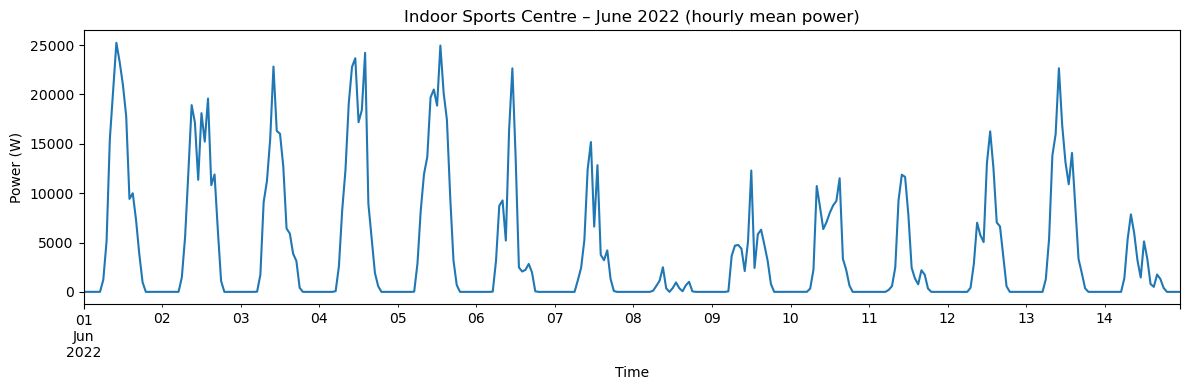

In [2]:
# AI-assisted revision (OpenAI Codex):
# AI was used to help restructure the data-loading pipeline so that all sites share a 
# common date range and resampling cadence. Final code was reviewed, edited, and integrated manually.
def find_data_root(start: Path) -> Path:
    """
    Search upwards from the current working directory to locate the dataset root.

    This avoids hard-coding an absolute path, making the notebook more portable
    across different machines or folder locations.
    """
    for p in [start, *start.parents]:
        for d in p.iterdir():
            if d.is_dir() and "doi_10_5061_dryad_m37pvmd99__v20240908" in d.name:
                return d
    raise FileNotFoundError("Could not locate dataset root containing 'doi_10_5061_dryad_m37pvmd99__v20240908'.")


# Locate the top-level dataset directory from the current working directory.
DATA_ROOT = find_data_root(Path.cwd())


# Path to PV site data for systems with panel-level optimisers.
PV_SITE_WITH_OPT = (
    DATA_ROOT
    / "Dataset" / "Dataset"
    / "Time series dataset"
    / "PV generation dataset"
    / "PV stations with panel level optimizer"
    / "Site level dataset"
)

# Path to PV site data for systems without panel-level optimisers.
PV_SITE_WITHOUT_OPT = (
    DATA_ROOT
    / "Dataset" / "Dataset"
    / "Time series dataset"
    / "PV generation dataset"
    / "PV stations without panel level optimizer"
    / "Site level dataset"
)

# Path to meteorological time-series data.
METEO_ROOT = (
    DATA_ROOT
    / "Dataset" / "Dataset"
    / "Time series dataset"
    / "Meteorological dataset"
)

# Path to installation metadata file.
METADATA_FILE = (
    DATA_ROOT
    / "Dataset" / "Dataset"
    / "Metadata"
    / "PV generation system metadata.ttl"
)


def detect_time_col(cols):
    """
    Detect the timestamp column by looking for common time-related keywords.

    This makes the loader more flexible if column names vary slightly between files.
    """
    for c in cols:
        if any(k in c.lower() for k in ["time", "date", "timestamp"]):
            return c
    return None


def detect_power_col(cols):
    """
    Detect the PV power column by looking for common power-related keywords.

    The first matching candidate is returned.
    """
    candidates = [c for c in cols if ("power" in c.lower()) or ("pac" in c.lower()) or ("activepower" in c.lower())]
    return candidates[0] if candidates else None


def load_single_site_csv(folder: Path, filename=None):
    """
    Load one PV site CSV file and perform basic cleaning.

    Steps:
    1. Find a CSV file in the target folder.
    2. Read the raw table.
    3. Detect the time and power columns automatically.
    4. Convert timestamps to datetime.
    5. Drop rows with invalid timestamps.
    6. Sort by time and restrict to the configured date range.

    Returns
    -------
    raw : pd.DataFrame
        Cleaned dataframe indexed by timestamp.
    power_col : str
        Name of the detected power column.
    f.name : str
        Filename actually used.
    """
    files = sorted(folder.glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    # Use the requested filename if provided; otherwise fall back to the first CSV.
    if filename:
        f = folder / filename
        if not f.exists():
            f = files[0]
    else:
        f = files[0]

    raw = pd.read_csv(f, na_values=["NA"])

    # Automatically identify the timestamp and PV power columns.
    time_col = detect_time_col(raw.columns)
    power_col = detect_power_col(raw.columns)
    if not time_col or not power_col:
        raise ValueError("Could not detect time/power columns in PV file")

    # Convert timestamp strings to pandas datetime objects.
    raw[time_col] = pd.to_datetime(raw[time_col], errors="coerce")

    # Drop invalid timestamps, set time as the index, and sort chronologically.
    raw = raw.dropna(subset=[time_col]).set_index(time_col).sort_index()

    # Restrict the dataset to the configured project date range.
    raw = raw.loc[CONFIG["DATE_START"]:CONFIG["DATE_END"]]

    return raw, power_col, f.name


def infer_steps_per_day(index: pd.DatetimeIndex):
    """
    Estimate the sampling frequency in units of samples per day.

    This is inferred from the most common time difference between consecutive rows.
    """
    dt = index.to_series().diff().dropna().mode().iloc[0]
    return int(pd.Timedelta("1D") / dt)


def resample_power_frame(df: pd.DataFrame, power_col: str, freq: str) -> pd.DataFrame:
    """
    Resample the power time series onto a common time grid.

    The power column is converted to numeric values, restricted to the analysis
    window, then averaged onto the chosen resampling frequency.
    """
    out = df[[power_col]].copy()
    out[power_col] = pd.to_numeric(out[power_col], errors="coerce")
    out = out.sort_index().loc[CONFIG["DATE_START"]:CONFIG["DATE_END"]]
    out = out.resample(freq).mean() # Use mean power within each hourly bin
    return out.dropna(subset=[power_col])


# Load a representative single PV site for initial inspection and plotting.
single_df, power_col, single_filename = load_single_site_csv(PV_SITE_WITH_OPT, CONFIG["DEFAULT_SITE_FILENAME"])

# Resample the power series to the common hourly grid used throughout the notebook.
pv = resample_power_frame(single_df, power_col, CONFIG["COMMON_FREQ"]).rename(columns={power_col: "power_W"})

# Add simple calendar/time features for exploratory analysis and later modelling.
pv["hour"] = pv.index.hour
pv["dayofyear"] = pv.index.dayofyear
pv["weekday"] = pv.index.weekday

# Estimate how many samples occur per day after resampling.
steps_per_day = infer_steps_per_day(pv.index)

# Sanity check: after resampling to 1h, there should be exactly 24 steps per day.
# If this fails, the resampling cadence has changed and lag features will be wrong.
assert steps_per_day == 24, (
    f"Expected 24 steps/day for hourly data, got {steps_per_day}. "
    f"Check COMMON_FREQ='{CONFIG['COMMON_FREQ']}' and the resampled index."
)

print("Single-site file:", single_filename)
print("Detected power column:", power_col)
print("Common frequency:", CONFIG["COMMON_FREQ"])
print("Steps per day:", steps_per_day)

# Quick sanity-check plot:
# inspect whether the time index and hourly averaging look sensible for one month.
pv["power_W"].loc["2022-06-01":"2022-06-14"].plot(figsize=(12, 4))
plt.title("Indoor Sports Centre – June 2022 (hourly mean power)")
plt.ylabel("Power (W)")
plt.tight_layout()
plt.show()


## 2. Meteorological data integration

This section loads the on-site weather data, converts the raw files into a consistent tabular format, and aligns the meteorological measurements with the PV power series.

The main steps are:
- reading weather files from multiple folders and file formats,
- parsing timestamps into a common datetime index,
- converting weather variables to numeric values,
- renaming columns using consistent prefixes,
- resampling all weather measurements to the common hourly grid,
- and joining the weather data to the PV dataset.

This produces a single time-aligned dataframe containing PV power and weather features for later exploratory analysis, feature engineering, and model training.

  Irradiance           (irr_): 1 columns
  Temperature          (temp_): 1 columns
  Relative Humidity    (rh_): 1 columns
  Wind                 (wind_): 2 columns
  Rainfall             (rain_): 1 columns
  Visibility           (vis_): 1 columns
  Sea Level Pressure   (slp_): 1 columns


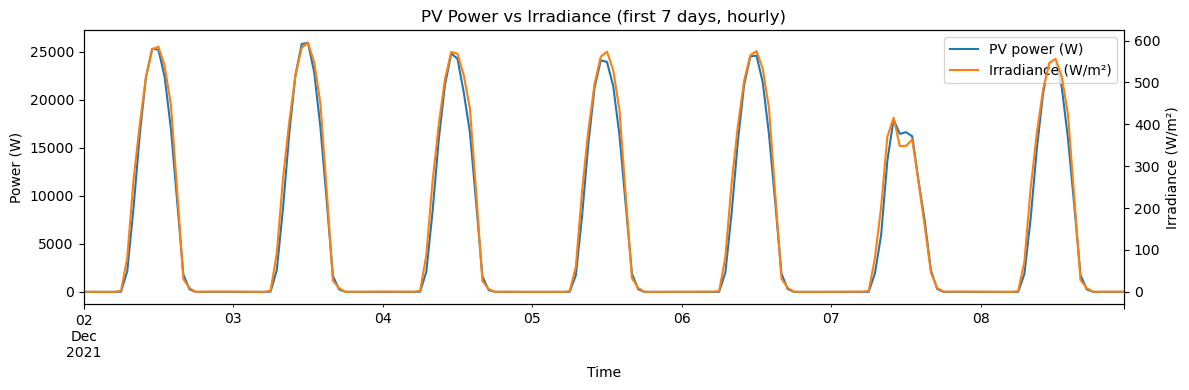

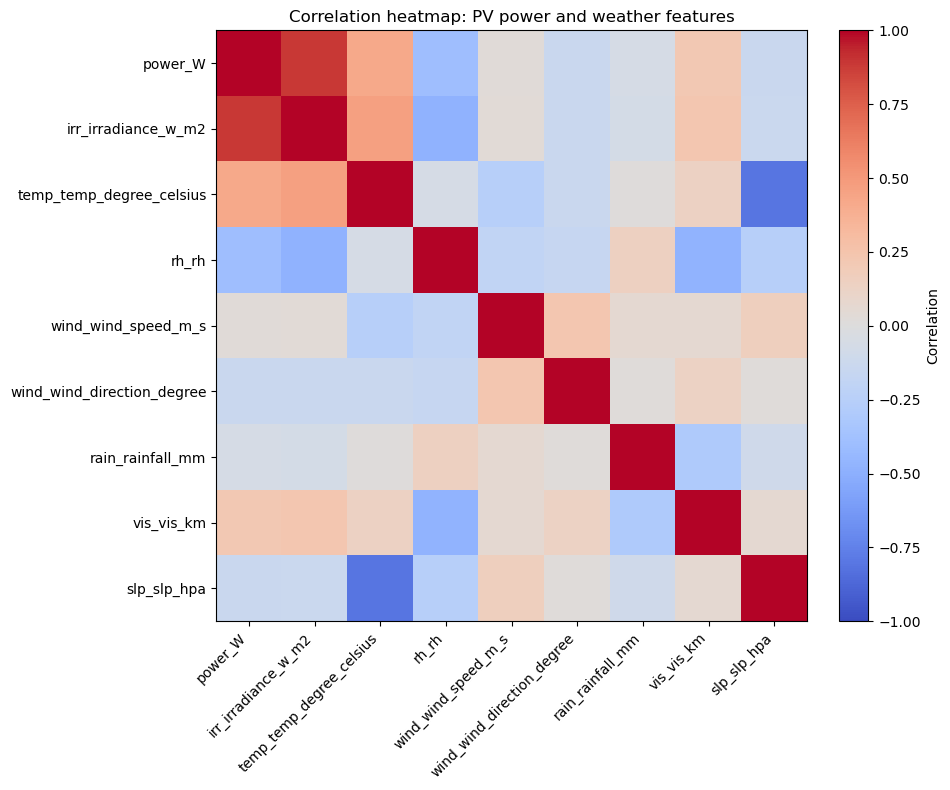

In [3]:
# AI-assisted revision (OpenAI Codex):
# AI was used to help restructure the weather-data loader so that mixed CSV/XLSX inputs could 
# be handled more robustly. Final code was reviewed, edited, and integrated manually.
def clean_col(name: str) -> str:
    """
    Standardise column names for easier downstream processing.

    Converts names to lowercase and replaces non-alphanumeric characters
    with underscores so that variables have a consistent naming convention.
    """
    name = name.lower()
    name = re.sub(r"[^a-z0-9]+", "_", name).strip("_")
    return name


def read_simple_xlsx(file_path: Path) -> pd.DataFrame:
    """
    Fallback XLSX reader using the raw XML structure inside an Excel file.

    This is used only if pandas/openpyxl cannot read an .xlsx file directly.
    It helps avoid silently dropping weather files because of engine or format
    issues.
    """
    import zipfile
    import xml.etree.ElementTree as ET

    ns = {"main": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}
    with zipfile.ZipFile(file_path) as zf:
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in root.findall("main:si", ns):
                text_parts = [node.text or "" for node in si.iterfind(".//main:t", ns)]
                shared_strings.append("".join(text_parts))

        # Read the first worksheet found in the workbook.
        sheet_name = next(name for name in zf.namelist() if name.startswith("xl/worksheets/sheet"))
        root = ET.fromstring(zf.read(sheet_name))

        rows = []
        for row in root.findall(".//main:sheetData/main:row", ns):
            values = []
            for cell in row.findall("main:c", ns):
                cell_type = cell.get("t")
                value_node = cell.find("main:v", ns)
                inline_node = cell.find("main:is/main:t", ns)
                if inline_node is not None:
                    value = inline_node.text or ""
                elif value_node is None:
                    value = ""
                else:
                    value = value_node.text or ""
                    if cell_type == "s" and value:
                        value = shared_strings[int(value)]
                values.append(value)
            rows.append(values)

    if not rows:
        return pd.DataFrame()
    header = rows[0]
    body = rows[1:]
    return pd.DataFrame(body, columns=header)


def read_tabular_file(file_path: Path) -> pd.DataFrame:
    """
    Read a weather file in CSV or XLSX format.

    CSV files are read directly with pandas. XLSX files are first attempted with
    pandas, with a simple XML-based fallback reader if that fails.
    """
    if file_path.suffix.lower() == ".csv":
        return pd.read_csv(file_path)
    if file_path.suffix.lower() == ".xlsx":
        try:
            return pd.read_excel(file_path)
        except Exception as exc:
            return read_simple_xlsx(file_path)
    raise ValueError(f"Unsupported meteorology file type: {file_path.name}")


def parse_meteo_time(series: pd.Series) -> pd.Series:
    """
    Parse meteorological timestamps into pandas datetime format.

    Handles two cases:
    1. Excel-style serial date numbers.
    2. Standard string-based datetime values.
    """
    numeric = pd.to_numeric(series, errors="coerce")

    # If most entries are numeric and fall in a plausible Excel serial-date range,
    # interpret them as Excel day counts from the standard origin.
    if not numeric.empty and numeric.notna().mean() > 0.8:
        valid_numeric = numeric.dropna()
        if not valid_numeric.empty and valid_numeric.between(30000, 60000).mean() > 0.8:
            return pd.to_datetime(numeric, unit="D", origin="1899-12-30", errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def load_meteo_folder(folder: Path, prefix: str) -> pd.DataFrame:
    """
    Load all supported weather files from one meteorological subfolder.

    Steps:
    1. Read each CSV/XLSX file.
    2. Detect the timestamp column.
    3. Parse timestamps and set them as the index.
    4. Restrict data to the configured analysis window.
    5. Convert remaining columns to numeric values.
    6. Prefix column names so variables remain identifiable after merging.

    Returns a single dataframe for that weather category.
    """
    frames = []
    for file in sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in {".csv", ".xlsx"}):
        df = read_tabular_file(file)

        # Identify the first likely timestamp column.
        time_cols = [c for c in df.columns if "time" in c.lower() or "date" in c.lower()]
        if not time_cols:
            raise ValueError(f"No time column found in {file}")
        time_col = time_cols[0]

        # Parse timestamps, remove invalid rows, and sort in time order.
        df[time_col] = parse_meteo_time(df[time_col])
        df = df.dropna(subset=[time_col]).set_index(time_col).sort_index()

        # Restrict to the common project date range.
        df = df.loc[CONFIG["DATE_START"]:CONFIG["DATE_END"]]

        # Convert weather measurements to numeric form where possible.
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
        df = df.select_dtypes(include="number")

        # Prefix columns by variable type (e.g. irr_, temp_, wind_) so that
        # similarly named columns from different folders do not collide.
        df = df.rename(columns=lambda c: f"{prefix}{clean_col(c)}")
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No supported tabular files found in {folder}")

    # Concatenate all files in this weather category and remove duplicate timestamps.
    out = pd.concat(frames).sort_index()
    out = out[~out.index.duplicated(keep="first")]
    return out


# Mapping from meteorological folder names to variable-name prefixes.
METEO_FOLDERS = {
    "Irradiance": "irr_",
    "Temperature": "temp_",
    "Relative Humidity": "rh_",
    "Wind": "wind_",
    "Rainfall": "rain_",
    "Visibility": "vis_",
    "Sea Level Pressure": "slp_",
}

# Load each weather category separately, then combine them into one dataframe.
meteo_frames = []
for folder, prefix in METEO_FOLDERS.items():
    meteo_frames.append(load_meteo_folder(METEO_ROOT / folder, prefix))

meteo = pd.concat(meteo_frames, axis=1).sort_index()
meteo = meteo[~meteo.index.duplicated(keep="first")]
meteo = meteo.loc[CONFIG["DATE_START"]:CONFIG["DATE_END"]]

# Aggregate weather variables to the common hourly grid used for PV data.
# Rainfall is summed over the hour, while most other measurements are averaged.
weather_agg = {col: ("sum" if col.startswith("rain_") else "mean") for col in meteo.columns}
meteo_common = meteo.resample(CONFIG["COMMON_FREQ"]).agg(weather_agg)

# Forward-fill only short gaps after hourly resampling so that isolated missing
# weather timestamps do not force row deletion. The fill length is kept small to
# avoid creating long artificial runs of constant weather values.
meteo_common = meteo_common.ffill(limit=3)

# Join weather data onto the PV dataframe using the common hourly timestamps.
pv_weather = pv.join(meteo_common.reindex(pv.index), how="left")

# Collect the weather-feature column names for later modelling and inspection.
weather_cols = [c for c in pv_weather.columns if c.startswith(CONFIG["WEATHER_PREFIXES"])]

# --- Diagnostic: check which weather variable groups were loaded ---
for prefix_label, prefix in METEO_FOLDERS.items():
    matched = [c for c in weather_cols if c.startswith(prefix)]
    status = f"{len(matched)} columns" if matched else "*** MISSING ***"
    print(f"  {prefix_label:20s} ({prefix}): {status}")

rain_cols = [c for c in weather_cols if c.startswith("rain_")]
if not rain_cols:
    print("\n⚠ WARNING: No rainfall columns found. Check the 'Rainfall' subfolder in METEO_ROOT.")
    print(f"  Expected path: {METEO_ROOT / 'Rainfall'}")
    print(f"  Files present: {list((METEO_ROOT / 'Rainfall').iterdir()) if (METEO_ROOT / 'Rainfall').exists() else 'FOLDER NOT FOUND'}")

# Use irradiance, if available, for a simple physical sanity-check plot.
# Use the first available irradiance variable for the sanity check, not necessarily the
#best one. For a quick validation plot that is okay.
irr_cols = [c for c in pv_weather.columns if c.startswith("irr_")]
irr_col = irr_cols[0] if irr_cols else None

if irr_col:
    plot_idx = pv_weather.index[: steps_per_day * 7]

    fig, ax1 = plt.subplots(figsize=(12, 4))
    pv_weather.loc[plot_idx, "power_W"].plot(ax=ax1, color="tab:blue", label="PV power (W)")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Power (W)")

    ax2 = ax1.twinx()
    pv_weather.loc[plot_idx, irr_col].plot(ax=ax2, color="tab:orange", label="Irradiance (W/m²)")
    ax2.set_ylabel("Irradiance (W/m²)")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right")
    ax1.set_title("PV Power vs Irradiance (first 7 days, hourly)")
    plt.tight_layout()
    plt.show()

# Correlation heatmap to inspect broad linear relationships between PV output
# and the available weather variables.
corr = pv_weather[["power_W"] + weather_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation heatmap: PV power and weather features")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
plt.tight_layout()
plt.show()


## 3. Multi-site PV dataset

This section constructs a combined dataset across all PV installations so that models can be trained on more than one site.

The metadata text file is parsed to extract installation-level properties such as rated power, tilt, azimuth, altitude, connection year, and optimiser status. Each site power series is then loaded, resampled to the common hourly grid, and linked to its metadata entry using standardised site names.

Finally, the PV data, metadata, and weather variables are merged into a single dataframe. Power is also normalised by rated system capacity to form a per-unit target, allowing more meaningful comparison across installations of different sizes.


In [4]:
# AI-assisted revision (OpenAI Codex):
# AI was used to help parse the Brick metadata file and align metadata entries
# with the PV time-series files for normalisation and dataset checks.
# Final code was reviewed, edited, and integrated manually.


def canonical_site_name(name: str) -> str:
    """
    Standardise site names before matching metadata entries to PV filenames.

    This reduces differences caused by spelling variants, punctuation, and small naming 
    inconsistencies, making exact or fuzzy matching more reliable.
    """
    text = name.lower().replace("centre", "center").replace("sports", "sport")
    text = text.replace("phrase", "phase")
    return re.sub(r"[^a-z0-9]+", "", text)


def first_numeric(text):
    """
    Extract the first numeric value from a text field.

    Returns NaN if no valid number is found. This is used for metadata fields
    where values may be embedded inside descriptive text.
    """
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return np.nan
    match = re.search(r"-?\d+(?:\.\d+)?", str(text))
    return float(match.group()) if match else np.nan


def angle_to_components(angle_text):
    """
    Convert an azimuth angle into sine and cosine components.

    This avoids the discontinuity between 0 and 360 degrees and gives a more
    suitable representation for machine-learning models.
    """
    angle_value = first_numeric(angle_text)
    if np.isnan(angle_value):
        return np.nan, np.nan
    radians = np.deg2rad(angle_value)
    return np.sin(radians), np.cos(radians)


def extract_numeric_value(block: str, prop: str):
    """
    Extract a numeric metadata value from one Brick metadata block.

    Parameters
    ----------
    block : str
        One metadata text block.
    prop : str
        Property name to search for.

    Returns
    -------
    float
        Extracted numeric value, or NaN if not found.
    """
    match = re.search(rf"{re.escape(prop)}.*?brick:value\s+(-?\d+(?:\.\d+)?)", block, flags=re.S)
    return float(match.group(1)) if match else np.nan


def extract_string_value(block: str, prop: str):
    """
    Extract a string metadata value from one Brick metadata block.

    Parameters
    ----------
    block : str
        One metadata text block.
    prop : str
        Property name to search for.

    Returns
    -------
    str or None
        Extracted string value, or None if not found.
    """
    match = re.search(rf"{re.escape(prop)}.*?brick:value\s+\"([^\"]+)\"", block, flags=re.S)
    return match.group(1) if match else None


def parse_metadata_ttl(ttl_path: Path) -> pd.DataFrame:
    """
    Parse the PV metadata text file into a tabular dataframe.

    The output includes system capacity, tilt, azimuth, altitude, location,
    contractor, connection year, and derived orientation features.
    """
    text = ttl_path.read_text(encoding="utf-8")
    rows = []

    # Split the metadata file into blocks and keep only PV system entries.
    for block in re.split(r"\n\s*\n", text):
        if "a brick:PV_Generation_System" not in block:
            continue

        head = re.match(r"pvsystem:([^\s]+)\s+a brick:PV_Generation_System", block)
        if not head:
            continue

        raw_name = head.group(1)
        azimuth_text = extract_string_value(block, "ext:azimuth")
        tilt_text = extract_string_value(block, "ext:tiltAngle")
        contractor = extract_string_value(block, "ext:contractor")
        location = extract_string_value(block, "brick:hasLocation")
        connection_date = extract_string_value(block, "ext:connectionDate")

        # Represent azimuth using sine/cosine so circular direction is handled properly.
        azimuth_sin, azimuth_cos = angle_to_components(azimuth_text)
        rows.append({
            "canonical_key": canonical_site_name(raw_name),
            "metadata_name": raw_name,
            "location_name": location,
            "contractor": contractor,
            "connection_date": connection_date,
            "connection_year": first_numeric(connection_date),
            "altitude_m": extract_numeric_value(block, "ext:altitude"),
            "rated_power_kW": extract_numeric_value(block, "ext:ratedPowerOutput"),
            "tilt_deg": first_numeric(tilt_text),
            "azimuth_deg": first_numeric(azimuth_text),
            "azimuth_sin": azimuth_sin,
            "azimuth_cos": azimuth_cos,
            "mixed_orientation": int(azimuth_text is not None and "mixed" in azimuth_text.lower()),
        })

    # Deduplicate by canonical site key and use it as the metadata index.
    meta = pd.DataFrame(rows).drop_duplicates(subset=["canonical_key"]).set_index("canonical_key")
    return meta


def load_pv_site(file_path: Path, has_optimizer: int, preferred_power_col=None) -> pd.DataFrame:
    """
    Load one PV site CSV file and standardise it to the common notebook format.

    Steps:
    1. Detect the time and power columns.
    2. Load only the required columns.
    3. Parse timestamps and sort chronologically.
    4. Restrict to the configured date range.
    5. Convert power to numeric form.
    6. Resample to the common hourly cadence.
    7. Add site-level identifiers.
    """
    sample = pd.read_csv(file_path, nrows=5)

    # Detect the time column and, where possible, reuse the previously identified
    # power column name for consistency across files.
    time_col = detect_time_col(sample.columns)
    power_col = preferred_power_col if preferred_power_col in sample.columns else detect_power_col(sample.columns)
    if not time_col or not power_col:
        raise ValueError(f"Could not detect time/power columns in {file_path.name}")

    # Load only the columns needed for modelling.
    df = pd.read_csv(file_path, usecols=[time_col, power_col], na_values=["NA"])

    # Convert timestamps, drop invalid rows, and sort in chronological order.
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col]).set_index(time_col).sort_index()

    # Restrict each site to the common project date range.
    df = df.loc[CONFIG["DATE_START"]:CONFIG["DATE_END"]]

    # Convert PV output to numeric and rename it consistently.
    df[power_col] = pd.to_numeric(df[power_col], errors="coerce")
    df = df.rename(columns={power_col: "power_W"})

    # Resample to the common hourly grid so all sites share the same cadence.
    df = df.resample(CONFIG["COMMON_FREQ"]).mean() 

    # Add identifiers used later for grouping and metadata joins.
    df["site_id"] = file_path.stem
    df["has_optimizer"] = int(has_optimizer)

    return df[["power_W", "site_id", "has_optimizer"]].dropna(subset=["power_W"])


# Parse the installation metadata file into a structured dataframe.
metadata_df = parse_metadata_ttl(METADATA_FILE)

# Reuse the previously detected single-site power column name where possible,
# while still falling back to automatic detection for other files.
preferred_power = power_col

frames = []

# Load all PV sites from the two installation groups:
# systems with panel-level optimisers and systems without them.
for folder, flag in [(PV_SITE_WITH_OPT, 1), (PV_SITE_WITHOUT_OPT, 0)]:
    if not folder.exists():
        continue
    for f in sorted(folder.glob("*.csv")):
        frames.append(load_pv_site(f, has_optimizer=flag, preferred_power_col=preferred_power))


# Combine all sites into one long multi-site dataframe.
pv_all_sites = pd.concat(frames, axis=0).sort_index()
pv_all_sites = pv_all_sites.loc[CONFIG["DATE_START"]:CONFIG["DATE_END"]]


# Build a mapping from PV site IDs to metadata entries.
# First use exact matching on canonicalised names; if that fails, fall back to fuzzy 
# matching to handle small naming differences.
site_ids = sorted(pv_all_sites["site_id"].unique())
meta_keys = metadata_df.index.tolist()
site_to_meta_key = {}

for site_id in site_ids:
    key = canonical_site_name(site_id)
    if key in metadata_df.index:
        site_to_meta_key[site_id] = key
        continue
    matches = difflib.get_close_matches(key, meta_keys, n=1, cutoff=0.78)
    site_to_meta_key[site_id] = matches[0] if matches else None

# Store the site-to-metadata mapping for inspection and validation.
site_match_table = pd.DataFrame({
    "site_id": site_ids,
    "meta_key": [site_to_meta_key[s] for s in site_ids],
})


# Join metadata onto the PV time-series rows.
pv_all_sites["meta_key"] = pv_all_sites["site_id"].map(site_to_meta_key)
pv_all_sites = pv_all_sites.join(metadata_df, on="meta_key")

# Convert rated system capacity from kW to W so it is consistent with power_W.
pv_all_sites["rated_power_W"] = pv_all_sites["rated_power_kW"] * 1000.0

# Normalise PV output by rated system size so sites of different capacities
# can be compared on a common per-unit scale.
pv_all_sites["power_pu"] = pv_all_sites["power_W"] / pv_all_sites["rated_power_W"]

# Negative values are clipped because negative PV generation is not physically
# meaningful here and likely reflects sensor noise or preprocessing artefacts.
pv_all_sites["power_pu"] = pv_all_sites["power_pu"].clip(lower=0)

# Join the weather variables onto the multi-site PV dataframe.
# Weather is shared by timestamp and aligned to the same hourly grid.
pv_all_sites_weather = pv_all_sites.join(meteo_common[weather_cols], how="left")


# Basic validation checks on the combined multi-site dataset.
print("pv_all_sites_weather shape:", pv_all_sites_weather.shape)
print("total rows in pv_all_sites_weather:", len(pv_all_sites_weather))
print("sites with matched metadata:", site_match_table["meta_key"].notna().sum(), "/", len(site_match_table))
print("missing weather fraction (joined):")
print(pv_all_sites_weather[weather_cols].isna().mean().round(4))
site_match_table.head(10)


pv_all_sites_weather shape: (1161889, 26)
total rows in pv_all_sites_weather: 1161889
sites with matched metadata: 60 / 60
missing weather fraction (joined):
irr_irradiance_w_m2           0.0066
temp_temp_degree_celsius      0.0066
rh_rh                         0.0066
wind_wind_speed_m_s           0.0066
wind_wind_direction_degree    0.0066
rain_rainfall_mm              0.0000
vis_vis_km                    0.0066
slp_slp_hpa                   0.0066
dtype: float64


,site_id,meta_key
0,CYT (Station 1),cytstation1
1,CYT (Station 2),cytstation2
2,Indoor Sports Centre,indoorsportcenter
3,LSK North,lsknorth
4,LSK South,lsksouth
5,Library,library
6,S H Ho Sports Hall,shhosporthall
7,SQ Apartment1-12,sqapartment112
8,SQ Apartment13-24,sqapartment1324
9,SQ Apartment25-36,sqapartment2536


## 4. Feature engineering: lagged values and time-based features

This section creates additional predictor variables from the PV time series and timestamp index.

Two types of engineered features are used:
- **lag features**, which provide the model with recent past values of the target variable;
- **time features**, which describe repeating temporal patterns such as hour of day, day of week, and month of year.

Cyclical variables are encoded using sine and cosine transforms so that their periodic structure is represented smoothly. Additional features are also created for wind direction and daylight conditions where relevant.

In [5]:
def add_lags(df: pd.DataFrame, target_col: str, lags) -> pd.DataFrame:
    """
    Add lagged versions of the target column to a dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing the target column.
    target_col : str
        Name of the column to lag.
    lags : list or dict
        If a list, each lag value creates a column named lag_<n>.
        If a dict, keys are used as custom lag column names and values
        give the lag size.

    Returns
    -------
    pd.DataFrame
        Copy of the input dataframe with extra lag-feature columns added.

    Notes
    -----
    A lag feature at time t contains the target value from an earlier
    time step, so it gives the model access to recent history without
    leaking future information.
    """
    out = df.copy()
    if isinstance(lags, dict):
        # Use user-defined column names for each lag.
        for name, lag in lags.items():
            out[name] = out[target_col].shift(lag)
    else:
        # Automatically name lag columns as lag_<n>.
        for lag in lags:
            out[f"lag_{lag}"] = out[target_col].shift(lag)
    return out


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add cyclical calendar features derived from the datetime index.

    Features added:
    - hour of day (sin/cos)
    - day of week (sin/cos)
    - month of year (sin/cos)
    - wind direction (sin/cos), if present
    - daylight indicator from irradiance, if available

    Returns
    -------
    pd.DataFrame
        Copy of the input dataframe with additional engineered features.

    Notes
    -----
    Sine/cosine encoding is used for cyclical variables so that the model
    correctly recognises that values at the boundaries are close together
    (e.g. hour 23 is close to hour 0).
    """
    out = df.copy()

    # Extract basic calendar components from the datetime index.
    hour = out.index.hour
    dow = out.index.dayofweek
    month = out.index.month

    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
    out["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)

    # Wind direction is also a circular variable, so represent it with sine/cosine
    # rather than raw degrees.
    if "wind_wind_direction_degree" in out.columns:
        radians = np.deg2rad(out["wind_wind_direction_degree"])
        out["wind_dir_sin"] = np.sin(radians)
        out["wind_dir_cos"] = np.cos(radians)

    # Create a daylight indicator using irradiance if an irradiance column exists.
    # This can help the model distinguish daytime production periods from night.
    if irr_col and irr_col in out.columns:
        out["is_daylight"] = (out[irr_col] > CONFIG["DAYLIGHT_IRR_THRESHOLD"]).astype(int)

    return out


## 5. Train/test split per site (time-based)

This section splits each site's time series into training and test sets using chronological order.

A random split is not appropriate for forecasting, because it would mix past and future observations and could leak information into training. Instead, the earlier portion of each site's data is used for training and the later portion is reserved for testing.

This gives a more realistic evaluation of model performance on unseen future data.


In [6]:
def make_site_split(df_site: pd.DataFrame, train_frac: float = 0.8):
    """
    Split one site's time series into training and test sets in chronological order.

    Parameters
    ----------
    df_site : pd.DataFrame
        Data for a single PV site, indexed by time.
    train_frac : float, optional
        Fraction of samples assigned to the training set.

    Returns
    -------
    train : pd.DataFrame
        Earlier portion of the time series used for training.
    test : pd.DataFrame
        Later portion of the time series used for testing.

    Notes
    -----
    A time-based split is used instead of a random split because this is a
    forecasting problem. This avoids leakage of future information into training
    and gives a more realistic evaluation on unseen future data.
    """
    df_site = df_site.sort_index()
    split_idx = int(len(df_site) * train_frac)
    train = df_site.iloc[:split_idx]
    test = df_site.iloc[split_idx:]
    return train, test


## 6. Models and training function

This section defines the regression models used for forecasting and provides a shared training/prediction function.

The models included here are:
- **Linear Regression** as a simple baseline,
- **Ridge Regression** and **Lasso Regression** as regularised linear models,
- plus optional tree-based and neural-network models handled through the same interface.

A common training function is used so that models are fitted and evaluated in a consistent way. Input features are standardised when required, predictions are generated on the test set only, and outputs are clipped to a physically reasonable range.

In [7]:
def make_model(model_name: str, alpha=None, params=None, config=CONFIG):
    """
    Construct a regression model from its name.

    Parameters
    ----------
    model_name : str
        Name of the model to create.
    alpha : float or None, optional
        Regularisation strength for Ridge, Lasso, or MLP if relevant.
    params : dict or None, optional
        Additional model-specific parameters. If omitted, sensible defaults
        are used.
    config : dict
        Configuration dictionary containing default hyperparameters.

    Returns
    -------
    sklearn-like estimator
        Instantiated regression model ready to be fitted.

    Notes
    -----
    Linear Regression provides a simple baseline.
    Ridge and Lasso add regularisation to reduce overfitting and improve
    stability when features are correlated.
    """
    # Copy the parameter dictionary so the original input is not modified in place.
    params = {} if params is None else params.copy()

    if model_name == "Linear":
        # Ordinary least-squares linear regression baseline.
        return LinearRegression()
    
    if model_name == "Ridge":
        # Ridge regression uses L2 regularisation.
        return Ridge(alpha=config["RIDGE_ALPHA_DEFAULT"] if alpha is None else alpha)
    
    if model_name == "Lasso":
        # Lasso regression uses L1 regularisation and can shrink some coefficients strongly towards zero.
        return Lasso(alpha=config["LASSO_ALPHA_DEFAULT"] if alpha is None else alpha, max_iter=10000)
    
    if model_name == "Decision Tree":
        # Tree model with configurable depth and leaf size.
        params.setdefault("max_depth", None)
        params.setdefault("min_samples_leaf", 1)
        params.setdefault("random_state", config["TREE_RANDOM_STATE"])
        return DecisionTreeRegressor(**params)
    
    if model_name == "MLP":
        # Multilayer perceptron regressor with default settings chosen for this notebook.
        if alpha is not None and "alpha" not in params:
            params["alpha"] = alpha

        params.setdefault("hidden_layer_sizes", config["MLP_HIDDEN_LAYER_DEFAULT"])
        params.setdefault("alpha", config["MLP_ALPHA_DEFAULT"])
        params.setdefault("activation", "relu")
        params.setdefault("solver", "adam")
        params.setdefault("early_stopping", True)
        params.setdefault("validation_fraction", 0.1)
        params.setdefault("max_iter", config["MLP_MAX_ITER"])
        params.setdefault("random_state", config["MLP_RANDOM_STATE"])
        return MLPRegressor(**params)
    
    if model_name == "Random Forest":
        # Random Forest averages many decorrelated decision trees to reduce variance.
        # This ensemble approach typically outperforms a single tree by averaging out
        # individual trees' overfitting tendencies.
        params.setdefault("n_estimators", 100)
        params.setdefault("max_depth", None)
        params.setdefault("min_samples_leaf", 1)
        params.setdefault("random_state", config["TREE_RANDOM_STATE"])
        params.setdefault("n_jobs", -1)  # Use all CPU cores for speed
        return RandomForestRegressor(**params)

    if model_name == "Gradient Boosting":
        # Gradient Boosting builds trees sequentially, each correcting the residual
        # errors of the ensemble so far. This additive approach reduces bias and can
        # capture complex nonlinear relationships.
        params.setdefault("n_estimators", 200)
        params.setdefault("max_depth", 4)
        params.setdefault("learning_rate", 0.1)
        params.setdefault("min_samples_leaf", 5)
        params.setdefault("random_state", config["TREE_RANDOM_STATE"])
        return GradientBoostingRegressor(**params)
    
    raise ValueError(f"Unknown model_name: {model_name}")


def fit_predict_model(model_name: str, X_train, y_train, X_test, alpha=None, params=None, config=CONFIG):
    """
    Fit one model on the training set and return predictions on the test set.

    Parameters
    ----------
    model_name : str
        Name of the model to fit.
    X_train : array-like or pd.DataFrame
        Training features.
    y_train : array-like or pd.Series
        Training target values.
    X_test : array-like or pd.DataFrame
        Test features.
    alpha : float or None, optional
        Regularisation strength if relevant for the chosen model.
    params : dict or None, optional
        Additional model-specific parameters.
    config : dict
        Configuration dictionary.

    Returns
    -------
    pd.Series
        Predictions on the test set, indexed to match X_test.

    Notes
    -----
    Feature scaling is applied only to models that depend on feature magnitude,
    such as Linear, Ridge, Lasso, and MLP. Predictions are clipped to a
    physically reasonable range to avoid implausible negative or extreme outputs.
    """
    # Preserve the original test index so predictions can be returned
    # as a labelled pandas Series.
    test_index = X_test.index

    # Scale input features only for models that are sensitive to feature scale.
    # Tree-based models do not require standardisation because they split on
    # thresholds rather than relying on distances or coefficient magnitudes.
    use_scale = model_name in config["SCALE_MODELS"]
    if use_scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Build the selected model with the requested settings.
    model = make_model(model_name, alpha=alpha, params=params, config=config)

    # Suppress MLP convergence warnings so the notebook output stays readable.
    # The warning is common for neural-network training and does not always
    # indicate a failed model fit, especially during repeated experiments.
    with warnings.catch_warnings():
        if model_name == "MLP":
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
        model.fit(X_train, y_train)

    # Generate predictions on the held-out test set.
    y_pred = pd.Series(model.predict(X_test), index=test_index)

    # Clip predictions to a physically sensible range:
    # PV output should not be negative, and extremely large per-unit values are treated as implausible.
    y_pred = y_pred.clip(lower=0, upper=config["PREDICTION_CLIP_MAX"])

    return y_pred


## 7. Evaluation metrics

This section defines the error metrics used to compare forecasting models.

Both **RMSE** and **MAE** are included:
- **RMSE** gives more weight to larger errors,
- **MAE** measures the average absolute error more directly.

To make errors comparable across sites with different system sizes, the metrics are also normalised by the 95th percentile of the training target. Using a training-based scale avoids information leakage from the test set and provides a robust reference level that is less sensitive to extreme outliers than the maximum value.

In [8]:
def rmse(y_true, y_pred):
    """
    Compute the root mean squared error (RMSE).

    RMSE penalises larger errors more strongly than MAE because the errors
    are squared before averaging.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mae(y_true, y_pred):
    """
    Compute the mean absolute error (MAE).

    MAE measures the average magnitude of the forecast error without giving
    extra weight to large outliers.
    """
    return mean_absolute_error(y_true, y_pred)


def compute_p95_train(y_train: pd.Series):
    """
    Compute the 95th percentile of the training target values.

    This is used as a robust normalisation scale for comparing forecast errors
    across sites with different rated capacities or output levels.
    """
    return y_train.quantile(0.95)


def nrmse_p95(y_true, y_pred, p95):
    """
    Compute RMSE normalised by the training-set 95th percentile.

    Returning NaN avoids division by zero or by an invalid normalisation scale.
    """
    if p95 == 0 or np.isnan(p95):
        return np.nan
    return rmse(y_true, y_pred) / p95


def nmae_p95(y_true, y_pred, p95):
    """
    Compute MAE normalised by the training-set 95th percentile.

    Returning NaN avoids division by zero or by an invalid normalisation scale.
    """
    if p95 == 0 or np.isnan(p95):
        return np.nan
    return mae(y_true, y_pred) / p95


## 8. Multi-site evaluation setup

This section prepares the final site-specific modelling datasets used in the forecasting experiments. For each PV installation, the data is sorted in chronological order, lagged target features are created, the one-step-ahead prediction target is defined, and a separate train/test split is stored.

This step is included so that each site can be evaluated consistently on unseen future data while preserving the time-series structure of the problem. Processing sites independently keeps the forecasting task site-aware, but using a common preparation pipeline makes results comparable across installations.

Key modelling choices:
- the target is the per-unit PV output (`power_pu`), so errors can be compared more fairly across systems of different sizes
- lagged PV features and engineered time/weather features are used to provide short-term temporal context
- train/test splitting is chronological rather than random, which is essential for forecasting and helps avoid leakage from future observations
- sites with too little usable data are excluded, so models are only evaluated where training and test sets are meaningful

In [9]:
TARGET_COL = "power_pu"

# Use all weather predictors except the raw wind direction angle.
# Wind direction is handled separately via sine/cosine encoding so that circular behaviour is represented 
# properly and the artificial 0°/360° jump is avoided.
model_weather_cols = [c for c in weather_cols if c != "wind_wind_direction_degree"]

# Define the feature set used for per-site forecasting.
# This combines:
# - short-term PV memory via lagged target values
# - cyclical encodings for hour/day/month
# - a daylight indicator
# - meteorological predictors
feature_cols = [
    "lag_1",
    "lag_day",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_daylight",
] + model_weather_cols

# If raw wind direction is available, use its sine/cosine representation instead of the original angular variable.
if "wind_wind_direction_degree" in pv_all_sites_weather.columns:
    feature_cols += ["wind_dir_sin", "wind_dir_cos"]

# Remove any accidental duplicates while preserving the original order.
feature_cols = list(dict.fromkeys(feature_cols))


def prepare_site_frame(df_site: pd.DataFrame, features, target: str, config=CONFIG):
    """
    Prepare one site's dataset for time-series forecasting.

    The site data is sorted chronologically, checked for sufficient raw length,
    transformed into a supervised-learning table using lagged predictors and a
    one-step-ahead target, and then split into chronological train/test subsets.

    Parameters
    ----------
    df_site : pd.DataFrame
        Data for a single PV site.
    features : list[str]
        Predictor columns to retain in the final model table.
    target : str
        Name of the target column to forecast.
    config : dict, optional
        Configuration dictionary containing split fraction, forecast horizon,
        and minimum sample thresholds.

    Returns
    -------
    dict or None
        Dictionary containing raw and model-ready train/test data for the site,
        or None if the site does not contain enough usable samples.
    """
    # Ensure time order is correct before any lagging or splitting.
    # This is essential for forecasting and avoids mixing past and future data.
    df_site = df_site.sort_index()

    # Check whether the site has enough raw observations to justify inclusion.
    # This early filter avoids constructing model tables for sites that are too short to support 
    # meaningful train/test evaluation.
    raw_train, raw_test = make_site_split(df_site, config["TRAIN_FRAC"])
    if len(raw_train) < config["MIN_TRAIN_SAMPLES"] or len(raw_test) < config["MIN_TEST_SAMPLES"]:
        return None

    # Create lagged versions of the target so the model can use recent PV output as predictors. 
    # 'lag_1' captures short-term persistence; 'lag_day' captures daily repetition at the same hour.
    model_df = add_lags(df_site, target, {"lag_1": 1, "lag_day": steps_per_day})

    # Add cyclical calendar features and daylight indicator.
    model_df = add_time_features(model_df)

    # Define the forecasting target as the value H steps ahead.
    # Shifting by -H means each row uses information at time t to predict the target at time t + H.
    model_df["y_future"] = model_df[target].shift(-config["H"])

    # Remove rows that cannot be used for supervised learning because lagged inputs or the future target are unavailable.
    required = ["y_future", target] + features
    model_df = model_df.dropna(subset=required)

    # Split the supervised-learning table chronologically so evaluation is
    # performed on unseen future data rather than a random sample.
    train, test = make_site_split(model_df, config["TRAIN_FRAC"])
    if len(train) < config["MIN_TRAIN_SAMPLES"] or len(test) < config["MIN_TEST_SAMPLES"]:
        return None

    return {
        "full_raw": df_site,
        "raw_train": raw_train,
        "raw_test": raw_test,
        "model_df": model_df,
        "train": train,
        "test": test,
    }


# Build one prepared dataset per site.
# Grouping by site_id keeps each installation separate so the forecasting
# problem remains site-aware and evaluation can later be compared across sites.
site_splits = {}
for site_id, g in pv_all_sites_weather.groupby("site_id"):
    prepared = prepare_site_frame(g, feature_cols, target=TARGET_COL, config=CONFIG)
    if prepared is None:
        continue
    site_splits[site_id] = prepared

print("Prepared sites for modelling:", len(site_splits))
print("Feature count:", len(feature_cols))


Prepared sites for modelling: 60
Feature count: 18


## Debug check: site coverage and metadata consistency

This section performs a simple diagnostic check on the prepared multi-site datasets. For each retained site, it summarises the number of raw and model-ready train/test samples and records the matched rated power metadata.

This check is included to confirm that the site preparation stage has behaved as expected before fitting models. In particular, it verifies that:
- all retained sites have usable train/test splits after feature construction
- model-ready sample counts are close to the raw counts, aside from rows lost to lagging and forecast shifting
- metadata matching has succeeded for all prepared sites

Although this section is not part of the forecasting model itself, it is useful for validating the preprocessing pipeline and for catching data-joining or coverage problems early.

In [10]:
coverage_rows = []
for site_id, obj in site_splits.items():
    rated_power_W = obj["raw_train"]["rated_power_W"].dropna()
    coverage_rows.append({
        "site_id": site_id,
        "n_train_raw": len(obj["raw_train"]),
        "n_test_raw": len(obj["raw_test"]),
        "n_train_model": len(obj["train"]),
        "n_test_model": len(obj["test"]),
        # Keep one representative rated-power value per site for checking.
        "rated_power_W": rated_power_W.iloc[0] if not rated_power_W.empty else np.nan,
    })

# Convert to a table and sort by model training size for quick inspection.
coverage_df = pd.DataFrame(coverage_rows).sort_values("n_train_model", ascending=False)
print("Prepared-site coverage summary:")
print(coverage_df.describe(include="all").transpose())

# Convert to a table and sort by model training size for quick inspection.
print("Sites with missing metadata after matching:")
print(site_match_table[site_match_table["meta_key"].isna()].head(10))

# --- Leakage check: confirm train/test periods don't overlap ---
leakage_found = False
for site_id, obj in site_splits.items():
    train_end = obj["raw_train"].index.max()
    test_start = obj["raw_test"].index.min()
    if train_end >= test_start:
        print(f"⚠ LEAKAGE: site {site_id}: train ends {train_end}, test starts {test_start}")
        leakage_found = True

if not leakage_found:
    print("✓ No train/test leakage detected: all train periods end before test periods begin.")

Prepared-site coverage summary:
              count unique   top freq          mean          std     min  \
site_id          60     60  SQ19    1           NaN          NaN     NaN   
n_train_raw    60.0    NaN   NaN  NaN       15491.4  4040.831565  2892.0   
n_test_raw     60.0    NaN   NaN  NaN   3873.416667  1010.333781   723.0   
n_train_model  60.0    NaN   NaN  NaN  15366.816667   4032.50111  2793.0   
n_test_model   60.0    NaN   NaN  NaN   3842.083333  1008.082662   699.0   
rated_power_W  60.0    NaN   NaN  NaN  37180.166667  37253.53613  3720.0   

                   25%      50%      75%       max  
site_id            NaN      NaN      NaN       NaN  
n_train_raw    14600.0  17328.5  18124.0   19332.0  
n_test_raw     3650.25   4332.5   4532.0    4833.0  
n_train_model  14467.0  17203.5  17992.0   19207.0  
n_test_model   3617.25   4301.5   4498.0    4802.0  
rated_power_W  25000.0  32050.0  33300.0  249500.0  
Sites with missing metadata after matching:
Empty DataFrame
Colu

## 9. Site summary stats

This section builds a per-site summary table from the prepared dataset. For each retained PV installation, it records training/test sample counts, summary statistics of per-unit power output, simple checks of weather coverage, and selected metadata such as rated power, altitude, tilt, azimuth, optimiser status, and contractor.

This is included to characterise the sites before model comparison. In particular, it helps show how much variation exists across installations in size, output behaviour, and metadata, and it provides a quick check that the retained sites are physically plausible and reasonably well described by the available inputs.

A simple correlation between PV output and irradiance is also included as a descriptive diagnostic. This is not used as a performance metric, but it is useful for checking whether the training data broadly reflects the expected physical relationship between sunlight and power generation.

In [11]:
def build_site_summary(site_splits: dict, irr_col: str, target: str) -> pd.DataFrame:
    """
    Build a summary table describing each retained PV site.

    The summary is constructed from the training portion of each site's data.
    It includes sample counts, descriptive statistics of PV output, simple
    weather-coverage checks, and selected metadata for later interpretation.

    Parameters
    ----------
    site_splits : dict
        Dictionary of prepared site datasets, with one entry per site.
    irr_col : str
        Name of the irradiance column, if available.
    target : str
        Name of the target column to summarise.

    Returns
    -------
    pd.DataFrame
        Per-site summary table containing sample counts, power statistics,
        descriptive diagnostics, and selected metadata.
    """

    def safe_corr(a, b):
        """
        Compute a correlation only when enough valid data are available.

        Returning NaN avoids misleading values when there are too few paired
        observations, or when either variable has zero variance.
        """
        d = pd.concat([a, b], axis=1).dropna()
        if len(d) < 10:
            return np.nan
        if d.iloc[:, 0].std() == 0 or d.iloc[:, 1].std() == 0:
            return np.nan
        return float(d.iloc[:, 0].corr(d.iloc[:, 1]))

    rows = []

    for site_id, obj in site_splits.items():
        # Use only training data for all summary statistics to avoid leaking
        # test-period information into the site characterisation.
        raw_train = obj["raw_train"]

        # Treat site metadata as constant within each site and take one value.
        # These columns are repeated on every row because they came from a merge,
        # so the first non-null entry is representative.
        rated_power_W = raw_train["rated_power_W"].dropna()
        rated_power_W = rated_power_W.iloc[0] if not rated_power_W.empty else np.nan

        contractor = raw_train["contractor"].dropna()
        contractor = contractor.iloc[0] if not contractor.empty else None

        row = {
            "site_id": site_id,
            "n_train": len(raw_train),
            "n_test": len(obj["raw_test"]),

            # Basic descriptive statistics of the training target.
            "mean_power_pu": raw_train[target].mean(),
            "max_power_pu": raw_train[target].max(),
            "p95_power_pu": raw_train[target].quantile(0.95),
            "std_power_pu": raw_train[target].std(),

            # Fraction of timestamps where power is exactly zero.
            # A very high fraction suggests the site may be inactive or faulty.
            "frac_zero_power": (raw_train[target] == 0).mean(),

            # Pearson correlation between PV output and irradiance on training data.
            # A low value may indicate sensor problems, shading, or incorrect data alignment.
            "corr_power_irr": safe_corr(raw_train[target], raw_train[irr_col]) if irr_col and irr_col in raw_train.columns else np.nan,

            # Pearson correlation between PV output and irradiance on training data.
            # A low value may indicate sensor problems, shading, or incorrect data alignment.
            "frac_missing_weather": raw_train[weather_cols].isna().any(axis=1).mean() if weather_cols else np.nan,
            
            "rated_power_W": rated_power_W,
            
            # Ratio of observed peak power to the rated capacity from metadata.
            # Values well above 1.0 may indicate incorrect metadata or measurement errors.
            "max_vs_rated": raw_train["power_W"].max() / rated_power_W if pd.notna(rated_power_W) and rated_power_W > 0 else np.nan,

            # Same ratio at the 95th percentile, which is less sensitive to single spikes.
            "p95_vs_rated": raw_train["power_W"].quantile(0.95) / rated_power_W if pd.notna(rated_power_W) and rated_power_W > 0 else np.nan,

            # Installation-level metadata for potential use as model features
            # or for interpreting differences in forecasting performance across sites.
            "has_optimizer": int(raw_train["has_optimizer"].iloc[0]),
            "altitude_m": raw_train["altitude_m"].dropna().iloc[0] if raw_train["altitude_m"].notna().any() else np.nan,
            "tilt_deg": raw_train["tilt_deg"].dropna().iloc[0] if raw_train["tilt_deg"].notna().any() else np.nan,
            "azimuth_deg": raw_train["azimuth_deg"].dropna().iloc[0] if raw_train["azimuth_deg"].notna().any() else np.nan,
            "contractor": contractor,
        }
        rows.append(row)

    return pd.DataFrame(rows).sort_values("site_id").reset_index(drop=True)

summary_sites = build_site_summary(site_splits, irr_col, target=TARGET_COL)
print(summary_sites.head())


                site_id  n_train  n_test  mean_power_pu  max_power_pu  \
0       CYT (Station 1)    17892    4474       0.107011      0.988880   
1       CYT (Station 2)    18073    4519       0.147706      0.999920   
2  Indoor Sports Centre    14567    3642       0.130772      1.000492   
3             LSK North    18124    4532       0.150455      0.991824   
4             LSK South    17616    4405       0.148632      0.974478   

   p95_power_pu  std_power_pu  frac_zero_power  corr_power_irr  \
0      0.594952      0.194856         0.518332        0.879606   
1      0.704176      0.236219         0.488795        0.868991   
2      0.741414      0.238834         0.481637        0.860672   
3      0.706652      0.238505         0.471971        0.954722   
4      0.698967      0.234756         0.479905        0.956318   

   frac_missing_weather  rated_power_W  max_vs_rated  p95_vs_rated  \
0              0.002403        25000.0      0.988880      0.594952   
1              0.002379 

## 10. Outlier/anomaly rules + filtered sites

This section applies a set of rule-based quality filters to the per-site summary table from the previous section. Each rule targets a specific type of data problem that could distort model training or produce misleading evaluation results.

The rules are deliberately simple and interpretable rather than model-based. Sites are flagged if they have missing or implausible metadata, abnormally high or low power output relative to the fleet, weak physical correlation with irradiance, excessive missing weather data, or too little training history. All thresholds are defined in CONFIG so they can be adjusted and reviewed in one place.

Sites that trigger any rule are excluded from the model comparison. This filtering step is important because training on corrupted or unrepresentative data would reduce the reliability of the final results and make it harder to draw meaningful conclusions about which forecasting method works best.

Only training-period statistics are used for filtering, so no test-set information leaks into the site selection.

In [12]:
def flag_anomalies(summary_df: pd.DataFrame, rules_config: dict):
    """
    Apply rule-based quality filters to the per-site summary table.

    Each site is checked against a set of simple, interpretable rules that
    target common data-quality problems. Sites that trigger one or more rules
    are flagged as anomalies and excluded from later model evaluation.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Per-site summary table produced by build_site_summary().
    rules_config : dict
        Configuration dictionary containing the threshold for each rule.

    Returns
    -------
    summary_df : pd.DataFrame
        Updated summary table with 'anomaly_rules' and 'is_anomaly' columns added.
    filtered_site_ids : list
        Site IDs that passed all quality checks and are retained for modelling.
    """
    # Compute the interquartile range of p95 power across all sites.
    # This is used to identify statistical outliers in the fleet-level
    # distribution of per-unit output, following the standard IQR fence method.
    p95_q1 = summary_df["p95_power_pu"].quantile(0.25)
    p95_q3 = summary_df["p95_power_pu"].quantile(0.75)
    p95_iqr = p95_q3 - p95_q1

    def rule_list(row):
        """Check one site against all quality rules and return a list of triggered rule names."""
        rules = []

        # Rule 1: Missing or invalid rated power makes per-unit normalisation unreliable.
        if pd.isna(row["rated_power_W"]) or row["rated_power_W"] <= 0:
            rules.append("missing_rated_power")

        # Rule 2: Peak observed power far exceeds rated capacity.
        # This suggests incorrect metadata or a measurement fault.    
        if pd.notna(row["max_vs_rated"]) and row["max_vs_rated"] > rules_config["MAX_POWER_MULT"]:
            rules.append("max_vs_rated")

        # Rule 3: The site's p95 output is a statistical outlier compared to the fleet.
        # Uses a standard IQR fence: values above Q3 + k * IQR are flagged.    
        if pd.notna(row["p95_power_pu"]) and row["p95_power_pu"] > (p95_q3 + rules_config["P95_IQR_MULT"] * p95_iqr):
            rules.append("p95_outlier_iqr")

        # Rule 4: Very low correlation between power and irradiance.
        # Physically, PV output should track sunlight closely; a weak link
        # suggests sensor errors, heavy shading, or misaligned data.    
        if pd.notna(row["corr_power_irr"]) and row["corr_power_irr"] < rules_config["LOW_CORR_IRR"]:
            rules.append("low_corr_irr")

        # Rule 5: Power is zero for nearly all timestamps.
        # The site is likely inactive, disconnected, or incorrectly recorded.    
        if row["frac_zero_power"] > rules_config["ZERO_FRAC_MAX"]:
            rules.append("mostly_zero")

        # Rule 6: Zero variance in power output means the site reported a flat constant,
        # which provides no useful signal for a forecasting model to learn from.    
        if pd.notna(row["std_power_pu"]) and row["std_power_pu"] == 0:
            rules.append("constant_power")

        # Rule 7: Too many weather rows are missing.
        # Models that use meteorological features would be trained on heavily imputed
        # inputs, reducing forecast reliability.    
        if pd.notna(row["frac_missing_weather"]) and row["frac_missing_weather"] > rules_config["MAX_FRAC_MISSING_WEATHER"]:
            rules.append("missing_weather")

        # Rule 8: Not enough training data for the model to learn meaningful patterns.    
        if row["n_train"] < rules_config["MIN_TRAIN_SAMPLES"]:
            rules.append("short_train_window")

        return rules

    # Apply every rule to every site and record which rules were triggered.
    summary_df = summary_df.copy()
    summary_df["anomaly_rules"] = summary_df.apply(rule_list, axis=1)
    summary_df["is_anomaly"] = summary_df["anomaly_rules"].apply(lambda r: len(r) > 0)

    # Convert the list of triggered rules into a readable semicolon-separated string.
    summary_df["anomaly_rules"] = summary_df["anomaly_rules"].apply(lambda r: "; ".join(r) if r else "")

    # Keep only the sites that passed every check.
    filtered_site_ids = summary_df.loc[~summary_df["is_anomaly"], "site_id"].tolist()
    return summary_df, filtered_site_ids


summary_sites, filtered_site_ids = flag_anomalies(summary_sites, CONFIG)

print("Retained sites:", len(filtered_site_ids), "/", len(summary_sites))
print("Top removed sites (train-only diagnostics):")
print(summary_sites[summary_sites["is_anomaly"]][["site_id", "anomaly_rules", "max_vs_rated", "corr_power_irr"]].head(15))


Retained sites: 57 / 60
Top removed sites (train-only diagnostics):
                 site_id               anomaly_rules  max_vs_rated  \
34                   SQ9                max_vs_rated     41.978741   
36               Tower A  max_vs_rated; low_corr_irr    788.163936   
41  UG Hall4 Flexible PV  max_vs_rated; low_corr_irr      8.963054   

    corr_power_irr  
34        0.388322  
36        0.015770  
41        0.094416  


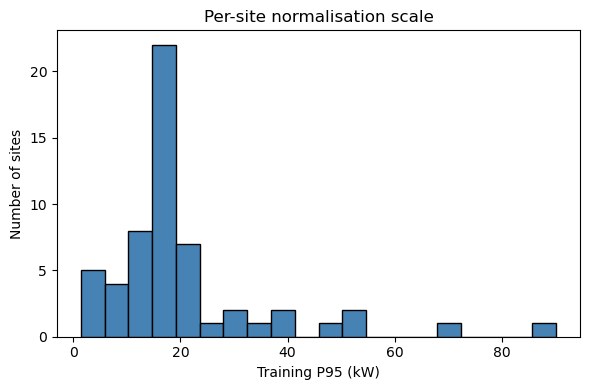

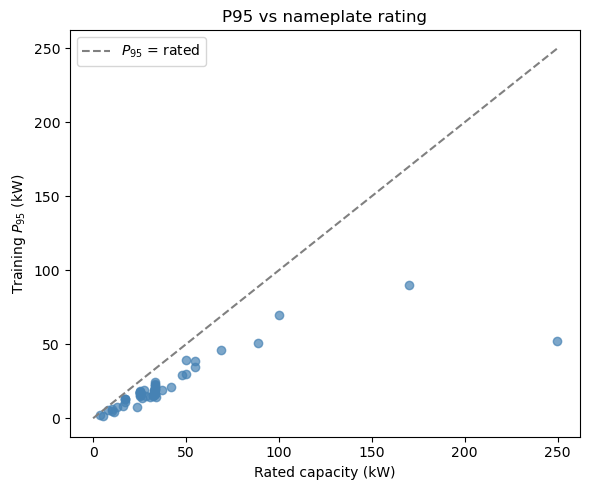

P95 range: 1.4 – 90.2 kW
P95 / rated ratio: median 0.60


In [13]:
# AI-assisted (Claude): diagnostic showing the normalisation scale used for NRMSE.
# Confirms the training-set P95 spans a wide range of per-site magnitudes,
# and that nameplate ratings systematically overstate actual peak output —
# justifying the use of training-set P95 rather than rated capacity.
import matplotlib.pyplot as plt
import numpy as np

# Pull per-site training P95 in Watts (using rated_power to convert back from per-unit).
p95_watts = []
rated_watts = []
for sid in filtered_site_ids:
    obj = site_splits[sid]
    train = obj["train"]
    raw_train = obj["raw_train"]
    p95_pu = compute_p95_train(train["y_future"])
    rated_W = raw_train["rated_power_W"].dropna().iloc[0] if "rated_power_W" in raw_train.columns else np.nan
    if not np.isnan(p95_pu) and not np.isnan(rated_W):
        p95_watts.append(p95_pu * rated_W)
        rated_watts.append(rated_W)

p95_watts = np.array(p95_watts)
rated_watts = np.array(rated_watts)

# --- Figure 1: P95 distribution across sites ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.hist(p95_watts / 1000, bins=20, color="steelblue", edgecolor="black")
ax1.set_xlabel("Training P95 (kW)")
ax1.set_ylabel("Number of sites")
ax1.set_title("Per-site normalisation scale")
plt.tight_layout()
plt.show()

# --- Figure 2: P95 vs rated capacity ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.scatter(rated_watts / 1000, p95_watts / 1000, alpha=0.7, color="steelblue")
lim = max(rated_watts.max(), p95_watts.max()) / 1000
ax2.plot([0, lim], [0, lim], "--", color="grey", label=r"$P_{95}$ = rated")
ax2.set_xlabel("Rated capacity (kW)")
ax2.set_ylabel(r"Training $P_{95}$ (kW)")
ax2.set_title("P95 vs nameplate rating")
ax2.legend()
plt.tight_layout()
plt.show()

print(f"P95 range: {p95_watts.min()/1000:.1f} – {p95_watts.max()/1000:.1f} kW")
print(f"P95 / rated ratio: median {np.median(p95_watts/rated_watts):.2f}")

## 11. Baselines: Persistence comparison (filtered sites)

This section evaluates a persistence baseline on all sites that passed the quality filters. The persistence forecast predicts that PV output H steps ahead will equal the current output, in other words, the simplest possible forecast that assumes nothing changes.

This is included because any useful forecasting model should beat persistence. If a more complex model cannot outperform this naive baseline, the added complexity is not justified. The persistence results also provide a common reference point for computing win rates and relative improvements in later sections.

Errors are normalised by the 95th percentile of the training target so that sites with different capacities can be compared on a common scale. The normalisation value is computed from training data only, avoiding information leakage from the test set.

The per-site predictions and irradiance series are cached here so that the daylight-versus-full-test comparison in a later section can reuse them without recomputing.

In [14]:
# Build persistence baseline on train-filtered sites
persist_results = []
persist_eval_cache = {}

for site_id in filtered_site_ids:
    obj = site_splits[site_id]
    train = obj["train"]
    test = obj["test"]

    # Normalisation scale: 95th percentile of the training target.
    # If this is zero or missing the site has no meaningful output range,
    # so skip it to avoid division-by-zero in normalised metrics.
    p95 = compute_p95_train(train["y_future"])
    if p95 == 0 or np.isnan(p95):
        continue

    # Persistence forecast: predict that power H steps ahead equals the current value.
    # Clipping keeps predictions within a physically plausible range (non-negative
    # and no higher than 1.5 per-unit, matching the upper bound used for all models).
    y_true = test["y_future"]
    y_pred = test[TARGET_COL].clip(lower=0, upper=CONFIG["PREDICTION_CLIP_MAX"])

    # Align on the inner index so that any rows lost to lagging or NaNs
    # are excluded from both sides of the comparison.
    y_pred, y_true = y_pred.align(y_true, join="inner")

    # Retrieve the test-period irradiance for this site, aligned to the same index.
    # This is stored for the daylight-only evaluation later, where only timestamps
    # with irradiance above a threshold are scored.
    irr_test = test[irr_col].reindex(y_true.index) if irr_col and irr_col in test.columns else None

    # Cache per-site results so the daylight comparison section can reuse them
    # without re-running the persistence loop.
    persist_eval_cache[site_id] = {
        "y_true": y_true.copy(),
        "y_pred": y_pred.copy(),
        "p95": p95,
        "irr": irr_test.copy() if isinstance(irr_test, pd.Series) else None,
    }

    # Record both raw and normalised error metrics for this site.
    persist_results.append({
        "site_id": site_id,
        "model": "Persistence",
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "NRMSE_p95": nrmse_p95(y_true, y_pred, p95),
        "NMAE_p95": nmae_p95(y_true, y_pred, p95),
    })

persist_df = pd.DataFrame(persist_results)
print("Persistence baseline shape:", persist_df.shape)
print(persist_df.groupby("model")[["NRMSE_p95", "NMAE_p95"]].mean().round(4))


Persistence baseline shape: (57, 6)
             NRMSE_p95  NMAE_p95
model                           
Persistence     0.3927    0.2414


## 12. Regularisation sensitivity sweep (filtered sites)

This section searches over hyperparameter configurations for each model class to find the best-performing settings, then evaluates those chosen settings on held-out test data.

The process uses a two-level splitting strategy to avoid data leakage:

1. **Inner split:** The training set for each site is further divided into an inner-training portion (85%) and an inner-validation portion (15%). All candidate hyperparameter configurations are fitted on the inner-training data and scored on the inner-validation data. The configuration with the lowest mean normalised RMSE across sites is selected for each model class.

2. **Final evaluation:** The selected settings are then retrained on the full training set and evaluated on the held-out test set. This ensures that the reported test-set results reflect genuine out-of-sample performance and are not optimistically biased by the hyperparameter selection process.

This approach follows standard practice for model selection in machine learning: hyperparameters are chosen using validation data, and final performance is measured on data that played no role in either training or selection.

The candidate configurations tested are:
- **Linear Regression:** no hyperparameters (single default setting).
- **Ridge:** regularisation strength alpha across several orders of magnitude.
- **Lasso:** regularisation strength alpha across several orders of magnitude.
- **Decision Tree:** combinations of maximum depth and minimum samples per leaf.
- **MLP:** combinations of hidden layer architecture and L2 regularisation strength.

A win-rate comparison against the Linear baseline on the inner validation split is also included to give a quick view of how often each setting outperforms the simplest model.

Summary (mean/median NRMSE_p95) [inner validation]:
                model                    setting_label  mean_NRMSE_p95  \
3       Decision Tree  max_depth=6, min_samples_leaf=1        0.195151   
4       Decision Tree  max_depth=6, min_samples_leaf=3        0.195672   
5       Decision Tree  max_depth=6, min_samples_leaf=5        0.195895   
0       Decision Tree  max_depth=4, min_samples_leaf=1        0.200061   
1       Decision Tree  max_depth=4, min_samples_leaf=3        0.200061   
2       Decision Tree  max_depth=4, min_samples_leaf=5        0.200305   
8       Decision Tree  max_depth=8, min_samples_leaf=5        0.204550   
7       Decision Tree  max_depth=8, min_samples_leaf=3        0.206225   
6       Decision Tree  max_depth=8, min_samples_leaf=1        0.206999   
9   Gradient Boosting               n_est=100, lr=0.05        0.184842   
11  Gradient Boosting               n_est=200, lr=0.05        0.187582   
10  Gradient Boosting                n_est=100, lr=0.1      

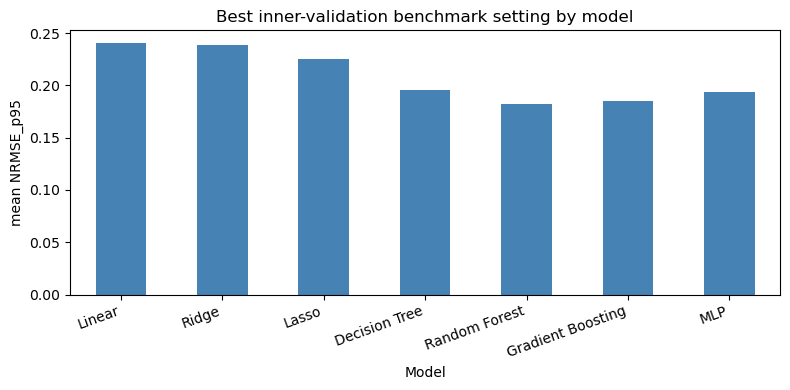

In [15]:
# AI-assisted revision (OpenAI Codex): I used AI to help refactor the
# benchmark selection so final results come from the tuned test set.

# --- Inner split fractions ---
# The training data is further split to create a validation set for hyperparameter
# selection. 85% is used for inner training and 15% for inner validation.
# A fallback fraction is provided in case the primary split produces an empty set
# (e.g. for sites with shorter time series).
INNER_TRAIN_FRAC = 0.85
FALLBACK_INNER_TRAIN_FRAC = 0.75

import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# === Decision Tree candidate configurations ===
# Grid over max_depth and min_samples_leaf to control tree complexity.
# Shallower trees and larger leaf sizes reduce overfitting but may underfit
# if the relationship between features and output is complex.
tree_settings = []
for max_depth in CONFIG["TREE_MAX_DEPTHS"]:
    for min_samples_leaf in CONFIG["TREE_MIN_SAMPLES_LEAF"]:
        tree_settings.append({
            "label": f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
            "alpha": None,
            "params": {
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
            },
        })

# === MLP candidate configurations ===
# Grid over hidden layer architecture and L2 regularisation strength (alpha).
# Architectures are kept deliberately small to remain course-appropriate and
# to avoid excessive training times across 57 sites.
mlp_settings = []
for hidden_layers in CONFIG["MLP_HIDDEN_LAYER_OPTIONS"]:
    hidden_label = "x".join(str(v) for v in hidden_layers)
    for alpha in CONFIG["MLP_ALPHAS"]:
        mlp_settings.append({
            "label": f"hidden={hidden_label}, alpha={alpha:g}",
            "alpha": None,
            "params": {
                "hidden_layer_sizes": hidden_layers,
                "alpha": alpha,
            },
        })

# === Random Forest candidate configurations ===
# Grid over n_estimators and max_depth. More estimators generally improve
# performance at the cost of training time; max_depth controls per-tree complexity.
rf_settings = []
for n_estimators in [50, 100, 200]:
    for max_depth in [6, 10, None]:
        depth_label = max_depth if max_depth is not None else "None"
        rf_settings.append({
            "label": f"n_est={n_estimators}, max_depth={depth_label}",
            "alpha": None,
            "params": {
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": 3,
            },
        })

# === Gradient Boosting candidate configurations ===
# Grid over n_estimators and learning_rate. A lower learning rate with more
# estimators typically gives better generalisation but takes longer to train.
gb_settings = []
for n_estimators in [100, 200]:
    for lr in [0.05, 0.1]:
        gb_settings.append({
            "label": f"n_est={n_estimators}, lr={lr}",
            "alpha": None,
            "params": {
                "n_estimators": n_estimators,
                "learning_rate": lr,
                "max_depth": 4,
                "min_samples_leaf": 5,
            },
        })

# === All candidate settings by model class ===
# Each model maps to a list of configurations to evaluate on the inner validation split.
# Linear has no tuneable hyperparameters so only one default entry is needed.
# Ridge and Lasso sweep over regularisation strength alpha.
candidate_settings = {
    "Linear": [
        {"label": "default", "alpha": None, "params": None},
    ],
    "Ridge": [
        {"label": f"alpha={alpha:g}", "alpha": alpha, "params": None}
        for alpha in CONFIG["RIDGE_ALPHAS"]
    ],
    "Lasso": [
        {"label": f"alpha={alpha:g}", "alpha": alpha, "params": None}
        for alpha in CONFIG["LASSO_ALPHAS"]
    ],
    "Decision Tree": tree_settings,
    "Random Forest": rf_settings,
    "Gradient Boosting": gb_settings,
    "MLP": mlp_settings,
}


def evaluate_setting(model_name: str, setting: dict, X_train, y_train, X_eval):
    """Fit one model with a specific hyperparameter setting and return test predictions."""
    return fit_predict_model(
        model_name,
        X_train,
        y_train,
        X_eval,
        alpha=setting.get("alpha"),
        params=setting.get("params"),
        config=CONFIG,
    )


def select_best_settings(summary_df: pd.DataFrame, candidates: dict):
    """
    For each model class, pick the hyperparameter setting with the lowest
    mean NRMSE_p95 on the inner validation split.

    Returns the best summary row and the corresponding setting dictionary
    for each model, which are then used for final test-set evaluation.
    """
    best_rows = {}
    best_settings = {}
    for model_name, settings in candidates.items():
        model_summary = summary_df[summary_df["model"] == model_name].sort_values("mean_NRMSE_p95")
        if model_summary.empty:
            continue
        best_row = model_summary.head(1).copy()
        best_rows[model_name] = best_row
        setting_lookup = {setting["label"]: setting for setting in settings}
        best_label = best_row["setting_label"].iloc[0]
        best_settings[model_name] = setting_lookup[best_label]
    return best_rows, best_settings

# =====================================================================
# PHASE 1: Inner validation sweep
# Fit every candidate configuration on the inner-training portion and
# score it on the inner-validation portion, for every filtered site.
# =====================================================================
validation_rows = []
test_rows = []
site_model_pred_cache = {}

for site_id in filtered_site_ids:
    obj = site_splits[site_id]
    train = obj["train"]
    test = obj["test"]

    p95 = compute_p95_train(train["y_future"])
    if p95 == 0 or np.isnan(p95):
        continue

    # Split the training data into inner-train and inner-validation subsets.
    # This chronological inner split mirrors the outer train/test split and
    # prevents the hyperparameter search from seeing future data.
    inner_split_idx = int(len(train) * INNER_TRAIN_FRAC)
    if inner_split_idx <= 0 or inner_split_idx >= len(train):
        inner_split_idx = int(len(train) * FALLBACK_INNER_TRAIN_FRAC)
    if inner_split_idx <= 0 or inner_split_idx >= len(train):
        continue

    train_inner = train.iloc[:inner_split_idx]
    val_inner = train.iloc[inner_split_idx:]
    if train_inner.empty or val_inner.empty:
        continue

    X_inner_train = train_inner[feature_cols]
    y_inner_train = train_inner["y_future"]
    X_inner_val = val_inner[feature_cols]
    y_inner_val = val_inner["y_future"]

    # Evaluate every candidate setting for every model on this site's validation split.
    for model_name, settings in candidate_settings.items():
        for setting in settings:
            pred = evaluate_setting(model_name, setting, X_inner_train, y_inner_train, X_inner_val)
            validation_rows.append({
                "site_id": site_id,
                "model": model_name,
                "setting_label": setting["label"],
                "NRMSE_p95": nrmse_p95(y_inner_val, pred, p95),
            })

# Aggregate validation results across sites to find the best setting per model.
results_sweep = pd.DataFrame(validation_rows)
summary_sweep = (
    results_sweep
    .groupby(["model", "setting_label"], dropna=False)
    .agg(mean_NRMSE_p95=("NRMSE_p95", "mean"),
         median_NRMSE_p95=("NRMSE_p95", "median"))
    .reset_index()
)

print("Summary (mean/median NRMSE_p95) [inner validation]:")
print(summary_sweep.sort_values(["model", "mean_NRMSE_p95"]))

# Select the single best hyperparameter configuration for each model class.
best_rows, best_model_settings = select_best_settings(summary_sweep, candidate_settings)

best_linear = best_rows.get("Linear", pd.DataFrame())
best_ridge = best_rows.get("Ridge", pd.DataFrame())
best_lasso = best_rows.get("Lasso", pd.DataFrame())
best_tree = best_rows.get("Decision Tree", pd.DataFrame())
best_mlp = best_rows.get("MLP", pd.DataFrame())

print("Best Ridge alpha:")
print(best_ridge)
print("Best Lasso alpha:")
print(best_lasso)
print("Best Decision Tree setting:")
print(best_tree)
print("Best MLP setting:")
print(best_mlp)

# =====================================================================
# PHASE 2: Final test-set evaluation
# Retrain each model using its selected settings on the FULL training set,
# then evaluate on the held-out test set. This gives unbiased performance
# estimates because the test data was not used during hyperparameter selection.
# =====================================================================
for site_id in filtered_site_ids:
    obj = site_splits[site_id]
    train = obj["train"]
    test = obj["test"]

    p95 = compute_p95_train(train["y_future"])
    if p95 == 0 or np.isnan(p95):
        continue

    X_train = train[feature_cols]
    y_train = train["y_future"]
    X_test = test[feature_cols]
    y_test = test["y_future"]

    # Fit each model's best configuration on the full training set and predict on test.
    model_predictions = {}
    for model_name, setting in best_model_settings.items():
        pred = evaluate_setting(model_name, setting, X_train, y_train, X_test)
        model_predictions[model_name] = pred.copy()
        test_rows.append({
            "site_id": site_id,
            "model": model_name,
            "RMSE": rmse(y_test, pred.copy()),
            "MAE": mae(y_test, pred.copy()),
            "NRMSE_p95": nrmse_p95(y_test, pred.copy(), p95),
            "NMAE_p95": nmae_p95(y_test, pred.copy(), p95),
        })

    # Cache predictions for the daylight-vs-full-test comparison later.
    site_model_pred_cache[site_id] = {
        "y_true": y_test.copy(),
        "p95": p95,
        "predictions": model_predictions,
        "selected_settings": {name: setting["label"] for name, setting in best_model_settings.items()},
    }

# Combine tuned model results with the persistence baseline into one table.
results_df = pd.DataFrame(test_rows)
filtered_metrics = results_df.copy()
results_filtered = pd.concat([filtered_metrics, persist_df], ignore_index=True)

# =====================================================================
# Win-rate analysis: how often does each candidate beat Linear Regression
# on the inner validation split? This gives a quick per-setting view of
# whether more complex models consistently outperform the simplest baseline.
# =====================================================================
lin_vals = results_sweep[results_sweep["model"] == "Linear"].set_index("site_id")["NRMSE_p95"]
win_rows = []
for model_name, settings in candidate_settings.items():
    if model_name == "Linear":
        continue
    for setting in settings:
        m = results_sweep[
            (results_sweep["model"] == model_name)
            & (results_sweep["setting_label"] == setting["label"])
        ].set_index("site_id")["NRMSE_p95"]
        common = lin_vals.index.intersection(m.index)
        win = (m.loc[common] < lin_vals.loc[common]).mean() * 100 if len(common) else np.nan
        win_rows.append({
            "model": model_name,
            "setting_label": setting["label"],
            "win_rate_vs_linear": win,
        })

win_rates = pd.DataFrame(win_rows)
print("Win-rate vs Linear (NRMSE_p95) [inner validation]:")
print(win_rates.sort_values(["model", "win_rate_vs_linear"], ascending=[True, False]))

# Bar chart showing the best configuration for each model class,
# ordered to match CONFIG["MODEL_ORDER"] for visual consistency.
best_setting_plot = (
    summary_sweep.sort_values("mean_NRMSE_p95")
    .groupby("model", group_keys=False)
    .head(1)
    .set_index("model")
)
best_setting_plot = best_setting_plot.reindex(
    [m for m in CONFIG["MODEL_ORDER"] if m != "Persistence" and m in best_setting_plot.index]
)

ax = best_setting_plot["mean_NRMSE_p95"].plot(kind="bar", figsize=(8, 4), color="steelblue")
ax.set_ylabel("mean NRMSE_p95")
ax.set_xlabel("Model")
ax.set_title("Best inner-validation benchmark setting by model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 13. Evaluation: Daylight vs Full-Test Comparison

This section compares model performance under two evaluation conditions: using all test-set timestamps (full test) and using only daylight timestamps (where irradiance exceeds a threshold).

The motivation is physical. PV panels produce zero power at night, so any model that predicts near-zero during darkness will appear accurate on those timestamps without having learned anything useful. Restricting evaluation to daylight hours removes this trivially correct portion and gives a more meaningful picture of how well each model forecasts the periods that actually matter for energy generation.

For each site, the irradiance series from the test period is used to construct a daylight mask. Both the full-test and daylight-only errors are computed using the same normalisation (training-set P95) so the two conditions are directly comparable.

A win-rate analysis is also included, showing what percentage of sites each model beats the persistence baseline under both conditions. This helps reveal whether models that look good on the full test are genuinely better during daylight, or whether their advantage comes mainly from easy nighttime predictions.

Daylight vs Full-Test NRMSE summary:
              split              model  mean_NRMSE_p95  median_NRMSE_p95
0       A_full_test      Decision Tree          0.1800            0.1638
1       A_full_test  Gradient Boosting          0.1614            0.1491
2       A_full_test              Lasso          0.2212            0.2096
3       A_full_test             Linear          0.2176            0.2094
4       A_full_test                MLP          0.1706            0.1581
5       A_full_test        Persistence          0.3927            0.3924
6       A_full_test      Random Forest          0.1686            0.1548
7       A_full_test              Ridge          0.2171            0.2085
8   B_daylight_only      Decision Tree          0.2316            0.2169
9   B_daylight_only  Gradient Boosting          0.2071            0.1910
10  B_daylight_only              Lasso          0.2868            0.2723
11  B_daylight_only             Linear          0.2861            0.2757
12  B_daylight

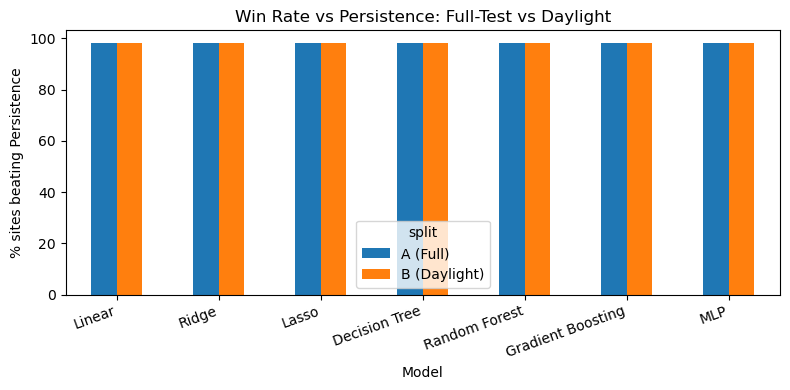

In [16]:
def compute_split_nrmse(y_true: pd.Series, y_pred: pd.Series, p95: float, mask: pd.Series) -> float:
    """
    Compute normalised RMSE on a masked subset of the test data.

    This is used to evaluate models on different subsets (e.g. full test vs
    daylight only) using the same normalisation scale for fair comparison.

    Parameters
    ----------
    y_true : pd.Series
        Actual target values.
    y_pred : pd.Series
        Predicted values.
    p95 : float
        Training-set 95th percentile used for normalisation.
    mask : pd.Series
        Boolean mask selecting which timestamps to include in the evaluation.

    Returns
    -------
    float
        Normalised RMSE on the masked subset, or NaN if the subset is empty.
    """
    eval_df = pd.concat([y_true.rename("y_true"), y_pred.rename("y_pred")], axis=1).dropna()
    if eval_df.empty or p95 == 0 or np.isnan(p95):
        return np.nan
    mask = mask.reindex(eval_df.index).fillna(False)
    eval_df = eval_df.loc[mask]
    if eval_df.empty:
        return np.nan
    return rmse(eval_df["y_true"], eval_df["y_pred"]) / p95


daylight_eval_rows = []

# Only evaluate sites that appear in both the persistence and model caches,
# so the comparison is always on the same set of sites.
common_site_ids = sorted(set(filtered_site_ids) & set(persist_eval_cache) & set(site_model_pred_cache))
comparison_models = [m for m in CONFIG["MODEL_ORDER"] if m != "Persistence"]


def _dedup_series_index(s: pd.Series) -> pd.Series:
    """
    If a series has duplicate timestamps (e.g. from overlapping resampling),
    collapse them by averaging. This prevents alignment errors when combining
    predictions from different sources into one dataframe.
    """
    if isinstance(s, pd.Series) and not s.index.is_unique:
        return s.groupby(level=0).mean()
    return s


for site_id in common_site_ids:
    persist_site = persist_eval_cache[site_id]
    model_site = site_model_pred_cache[site_id]

    # Retrieve and deduplicate the true values and persistence predictions.
    y_true = _dedup_series_index(persist_site["y_true"]).rename("y_true")
    y_pred_persist = _dedup_series_index(persist_site["y_pred"]).rename("Persistence")

    # Collect predictions from all tuned models for this site.
    model_preds = []
    for model_name in comparison_models:
        if model_name in model_site["predictions"]:
            pred_series = _dedup_series_index(model_site["predictions"][model_name]).rename(model_name)
            model_preds.append(pred_series)

    # Combine everything into one aligned dataframe, dropping any timestamps
    # where any model or the true value is missing.
    site_df = pd.concat([y_true, y_pred_persist] + model_preds, axis=1).dropna()

    if site_df.empty:
        continue

    # Build the daylight mask from the test-period irradiance.
    # Timestamps where irradiance exceeds the configured threshold are classified as daylight; 
    # all others are treated as night.
    irr_series = persist_site.get("irr")
    if isinstance(irr_series, pd.Series):
        irr_series = _dedup_series_index(irr_series).reindex(site_df.index)

    if isinstance(irr_series, pd.Series) and irr_series.notna().any():
        day_mask = irr_series > CONFIG["DAYLIGHT_IRR_THRESHOLD"]
    else:
        # If no irradiance data is available, fall back to an all-False mask
        # so the daylight split is empty rather than incorrectly including everything.
        day_mask = pd.Series(False, index=site_df.index)

    # Define the two evaluation conditions.
    split_masks = {
        "A_full_test": pd.Series(True, index=site_df.index), #  all timestamps
        "B_daylight_only": day_mask.fillna(False), # sunlight hours only
    }

    # Score every model under both conditions for this site.
    for split_name, split_mask in split_masks.items():
        for model_name in ["Persistence"] + [m for m in comparison_models if m in site_df.columns]:
            daylight_eval_rows.append(
                {
                    "site_id": site_id,
                    "split": split_name,
                    "model": model_name,
                    "NRMSE_p95": compute_split_nrmse(
                        site_df["y_true"],
                        site_df[model_name],
                        persist_site["p95"],
                        split_mask,
                    ),
                }
            )

# Aggregate across sites to get a single mean and median error per model per condition.
daylight_eval_df = pd.DataFrame(daylight_eval_rows).dropna(subset=["NRMSE_p95"])

daylight_summary = (
    daylight_eval_df.groupby(["split", "model"])["NRMSE_p95"]
    .agg(mean_NRMSE_p95="mean", median_NRMSE_p95="median")
    .reset_index()
)

print("Daylight vs Full-Test NRMSE summary:")
print(daylight_summary.round(4))

# =====================================================================
# Win-rate analysis: for each evaluation condition, compute what percentage
# of sites each model beats the persistence baseline on.
# This reveals whether a model's advantage is genuine during daylight
# or inflated by trivially correct nighttime predictions.
# =====================================================================
beat_rows = []
for split_name in ["A_full_test", "B_daylight_only"]:
    split_pivot = daylight_eval_df[daylight_eval_df["split"] == split_name].pivot(
        index="site_id", columns="model", values="NRMSE_p95"
    )
    if "Persistence" not in split_pivot.columns:
        continue

    for model_name in comparison_models:
        if model_name not in split_pivot.columns:
            continue
        cmp_df = split_pivot[["Persistence", model_name]].dropna()
        beat_rows.append(
            {
                "split": split_name,
                "model": model_name,
                "pct_sites_beating_persistence": (cmp_df[model_name] < cmp_df["Persistence"]).mean() * 100,
            }
        )

beat_df = pd.DataFrame(beat_rows)
print()
print("% sites where model beats persistence:")
print(beat_df.round(2))

# Bar chart comparing win rates under both conditions side by side.
plot_df = beat_df.pivot(index="model", columns="split", values="pct_sites_beating_persistence")
plot_df = plot_df.reindex(comparison_models)
plot_df = plot_df.rename(columns={"A_full_test": "A (Full)", "B_daylight_only": "B (Daylight)"})

ax = plot_df.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("% sites beating Persistence")
ax.set_xlabel("Model")
ax.set_title("Win Rate vs Persistence: Full-Test vs Daylight")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Daylight vs full-test NRMSE bar chart

The bar chart below contrasts mean NRMSE under the full 24-hour evaluation and under a daylight-only window (irradiance > 50 W/m²). Persistence relies on trivially-correct nighttime zeros to flatter its error; restricting to daylight hours is therefore a more physically meaningful comparison.

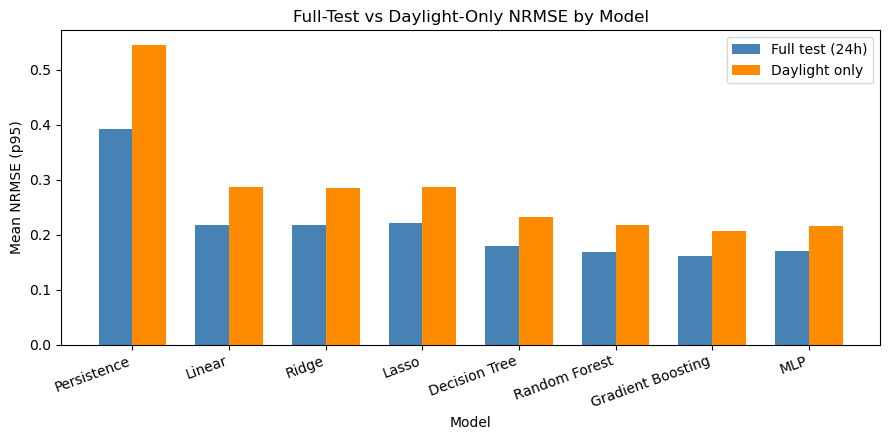

In [17]:
# AI-assisted addition (Claude): Daylight vs full-test NRMSE comparison chart.
models_order = [m for m in CONFIG["MODEL_ORDER"] if m in daylight_summary["model"].values]
full_vals = daylight_summary[daylight_summary["split"] == "A_full_test"].set_index("model").reindex(models_order)["mean_NRMSE_p95"]
day_vals = daylight_summary[daylight_summary["split"] == "B_daylight_only"].set_index("model").reindex(models_order)["mean_NRMSE_p95"]

x = np.arange(len(models_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
bars1 = ax.bar(x - width/2, full_vals.values, width, label="Full test (24h)", color="steelblue")
bars2 = ax.bar(x + width/2, day_vals.values, width, label="Daylight only", color="darkorange")
ax.set_ylabel("Mean NRMSE (p95)")
ax.set_xlabel("Model")
ax.set_title("Full-Test vs Daylight-Only NRMSE by Model")
ax.set_xticks(x)
ax.set_xticklabels(models_order, rotation=20, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Identify sites where persistence beats every supervised model.
# If the same site appears for all 7 models, the 98.2% win rate reflects one
# structurally-hard site rather than random per-model failures.
pivot = results_filtered.pivot_table(
    index="site_id", columns="model", values="NRMSE_p95", aggfunc="mean"
)
supervised = [m for m in pivot.columns if m != "Persistence"]

# Persistence wins for a given model if (model_NRMSE - persistence_NRMSE) > 0.
loses_to_persist = pivot[supervised].subtract(pivot["Persistence"], axis=0) > 0

# Site that loses for EVERY supervised model simultaneously.
loses_everywhere = pivot[loses_to_persist.all(axis=1)]
print("Sites where persistence beats every supervised model:")
print(loses_everywhere[["Persistence"] + supervised].round(3))

# For cross-reference: per-model list of the single losing site.
print("\nPer-model losing site (the one site each model loses to persistence on):")
for m in supervised:
    losers = pivot[pivot[m] > pivot["Persistence"]].index.tolist()
    print(f"  {m}: {losers}")

Sites where persistence beats every supervised model:
model              Persistence  Decision Tree  Gradient Boosting  Lasso  \
site_id                                                                   
SQ567 Flexible PV        0.133          0.256              0.229  0.184   

model              Linear    MLP  Random Forest  Ridge  
site_id                                                 
SQ567 Flexible PV   0.212  0.193          0.247  0.211  

Per-model losing site (the one site each model loses to persistence on):
  Decision Tree: ['SQ567 Flexible PV']
  Gradient Boosting: ['SQ567 Flexible PV']
  Lasso: ['SQ567 Flexible PV']
  Linear: ['SQ567 Flexible PV']
  MLP: ['SQ567 Flexible PV']
  Random Forest: ['SQ567 Flexible PV']
  Ridge: ['SQ567 Flexible PV']


## 14. Q1 — Per-site forecasting: results summary

This section answers the first part of the assignment brief: producing a model that predicts the output of a particular installation based on its own history. One model is fitted per site on that site’s own chronological training window and evaluated on its own held-out test window.

For each model, the summary below reports mean and median normalised RMSE across the 57 filtered sites on the held-out test set, mean normalised MAE, and mean raw RMSE and MAE. Daylight-only and full-test NRMSE from the previous section are merged in, along with each model’s win rate against the persistence baseline and the hyperparameter setting selected during the inner-validation sweep. A bar chart visualises the ranking, and a three-day test-window plot for one representative site then shows what the aggregate numbers mean in practice.

✓ Consistent: 57 sites across all result tables.
               model  mean_NRMSE_p95  median_NRMSE_p95  mean_NMAE_p95  \
0  Gradient Boosting          0.1614            0.1491         0.0843   
1      Random Forest          0.1686            0.1548         0.0852   
2                MLP          0.1706            0.1581         0.0931   
3      Decision Tree          0.1800            0.1638         0.0897   
4              Ridge          0.2171            0.2085         0.1492   
5             Linear          0.2176            0.2094         0.1492   
6              Lasso          0.2212            0.2096         0.1523   
7        Persistence          0.3927            0.3924         0.2414   

   mean_RMSE  mean_MAE  mean_NRMSE_full_test  mean_NRMSE_daylight  \
0     0.0913    0.0477                0.1614               0.2071   
1     0.0950    0.0480                0.1686               0.2179   
2     0.0968    0.0530                0.1706               0.2168   
3     0.1014    0

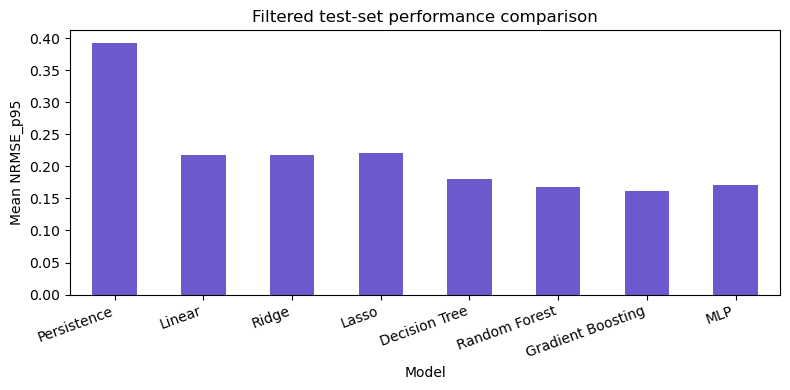

Top 5 best sites (filtered, mean across available models):
site_id
UG Hall8                 0.174667
Shaw Auditorium          0.175642
SQ Block P               0.177720
UG Hall9                 0.184825
SQ Block Q (Phrase 2)    0.189425
dtype: float64
Top 5 worst sites (filtered, mean across available models):
site_id
UG Hall2 2F                      0.232016
S H Ho Sports Hall               0.237607
Indoor Sports Centre             0.242676
SQ Apartment37-48 Flexible PV    0.325285
Zone A2                          0.722066
dtype: float64
Compact site-level comparison vs persistence (first 10 sites):
model                 Persistence  Decision Tree  Random Forest  \
site_id                                                           
CYT (Station 1)          0.405988       0.173163       0.167806   
CYT (Station 2)          0.383373       0.162449       0.155960   
Indoor Sports Centre     0.403158       0.231001       0.215822   
LSK North                0.393311       0.160027       0.

In [19]:
# --- Consistency check: confirm results_filtered and daylight_eval use the same sites ---
sites_in_results = set(results_filtered["site_id"].unique())
sites_in_daylight = set(daylight_eval_df["site_id"].unique()) if "daylight_eval_df" in globals() else set()
sites_in_persist = set(persist_df["site_id"].unique())

if sites_in_results != (sites_in_daylight | sites_in_persist):
    print("⚠ WARNING: Site sets differ between results_filtered and daylight evaluation.")
    print(f"  Results sites: {len(sites_in_results)}")
    print(f"  Daylight sites: {len(sites_in_daylight)}")
    print(f"  Persistence sites: {len(sites_in_persist)}")
    print("  Re-run from Cell 29 onwards in a single pass to fix.")
else:
    print(f"✓ Consistent: {len(sites_in_results)} sites across all result tables.")

# Aggregate the tuned test-set results across sites, one row per model.
model_summary = (
    results_filtered
    .groupby("model")
    .agg(
        mean_NRMSE_p95=("NRMSE_p95", "mean"),
        median_NRMSE_p95=("NRMSE_p95", "median"),
        mean_NMAE_p95=("NMAE_p95", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAE=("MAE", "mean"),
    )
    .reset_index()
)

# Sort by mean normalised RMSE so the best model appears first.
final_table = model_summary.copy().sort_values("mean_NRMSE_p95").reset_index(drop=True)

# Merge in the daylight vs full-test NRMSE from the previous section, if available.
# This adds two extra columns showing how each model performs when restricted
# to sunlight hours versus the full 24-hour test period.
if "daylight_summary" in globals() and not daylight_summary.empty:
    daylight_wide = daylight_summary.pivot(index="model", columns="split", values="mean_NRMSE_p95").reset_index()
    daylight_wide = daylight_wide.rename(
        columns={
            "A_full_test": "mean_NRMSE_full_test",
            "B_daylight_only": "mean_NRMSE_daylight",
        }
    )
    final_table = final_table.merge(daylight_wide, on="model", how="left")

# Compute win rate vs persistence: for each model, the percentage of sites
# where that model achieved a lower NRMSE than the persistence baseline.
pivot = results_filtered.pivot_table(index="site_id", columns="model", values="NRMSE_p95", aggfunc="mean")
win_rates = []
if "Persistence" in pivot.columns:
    for model_name in [m for m in CONFIG["MODEL_ORDER"] if m not in {"Persistence"}]:
        if model_name in pivot.columns:
            delta = pivot[model_name] - pivot["Persistence"]
            win_rates.append({"model": model_name, "win_rate_vs_persistence": (delta < 0).mean() * 100})
if win_rates:
    final_table = final_table.merge(pd.DataFrame(win_rates), on="model", how="left")

# Attach the hyperparameter setting that was selected for each model during
# the inner-validation sweep, so it is visible alongside the final results.
selected_setting_rows = []
if "best_model_settings" in globals():
    for model_name, setting in best_model_settings.items():
        selected_setting_rows.append({
            "model": model_name,
            "selected_setting": setting["label"],
        })
if selected_setting_rows:
    final_table = final_table.merge(pd.DataFrame(selected_setting_rows), on="model", how="left")

print(final_table.round(4))

print("Selected benchmark settings:")
for model_name in ["Ridge", "Lasso", "Decision Tree", "MLP"]:
    if "best_model_settings" in globals() and model_name in best_model_settings:
        print(f"  {model_name}: {best_model_settings[model_name]['label']}")

# Bar chart of mean normalised RMSE by model, ordered to match CONFIG["MODEL_ORDER"].
plot_order = [m for m in CONFIG["MODEL_ORDER"] if m in final_table["model"].tolist()]
plot_table = final_table.set_index("model").reindex(plot_order).dropna(subset=["mean_NRMSE_p95"])

ax = plot_table["mean_NRMSE_p95"].plot(kind="bar", figsize=(8, 4), color="slateblue")
ax.set_ylabel("Mean NRMSE_p95")
ax.set_xlabel("Model")
ax.set_title("Filtered test-set performance comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Per-site breakdown: identify the easiest and hardest sites to forecast,
# averaged across all model classes. This can help interpret whether certain
# installations have characteristics that make them inherently harder to predict.
if not pivot.empty:
    site_mean = pivot.mean(axis=1).sort_values()
    print("Top 5 best sites (filtered, mean across available models):")
    print(site_mean.head(5))
    print("Top 5 worst sites (filtered, mean across available models):")
    print(site_mean.tail(5))

    # Compact site-level table comparing the nonlinear models against persistence.
    # Boolean flags show whether Decision Tree / MLP beat persistence on each site.
    compact_cols = [c for c in ["Persistence", "Decision Tree", "Random Forest", "Gradient Boosting", "MLP"] if c in pivot.columns]
    compact_site_compare = pivot[compact_cols].copy()
    if {"Persistence", "Decision Tree"}.issubset(compact_site_compare.columns):
        compact_site_compare["tree_beats_persistence"] = compact_site_compare["Decision Tree"] < compact_site_compare["Persistence"]
    if {"Persistence", "Random Forest"}.issubset(compact_site_compare.columns):
        compact_site_compare["rf_beats_persistence"] = compact_site_compare["Random Forest"] < compact_site_compare["Persistence"]
    if {"Persistence", "Gradient Boosting"}.issubset(compact_site_compare.columns):
        compact_site_compare["gb_beats_persistence"] = compact_site_compare["Gradient Boosting"] < compact_site_compare["Persistence"]
    if {"Persistence", "MLP"}.issubset(compact_site_compare.columns):
        compact_site_compare["mlp_beats_persistence"] = compact_site_compare["MLP"] < compact_site_compare["Persistence"]

    print("Compact site-level comparison vs persistence (first 10 sites):")
    print(compact_site_compare.head(10))


### Q1 example: typical and hard cases

Two representative single-site forecasts are shown below. The left panel (typical case) is the filtered site whose Gradient Boosting NRMSE is closest to the median across the filtered fleet, so it illustrates the behaviour of the model on a site that performs close to average. The right panel (hard case) is Zone A2, a 249.5 kW installation identified in the leave-one-site-out analysis in Section 15.4 as the worst-case filtered site, likely because its multi-inverter configuration and mixed panel orientations are not captured by the static metadata features. Showing both panels gives a more honest picture of where the tuned model works and where it breaks.

Q1 typical-case site: SQ8
  GB NRMSE:          0.1491
  Persistence NRMSE: 0.4103
Q1 hard-case site: Zone A2
  GB NRMSE:          0.5546
  Persistence NRMSE: 1.0492


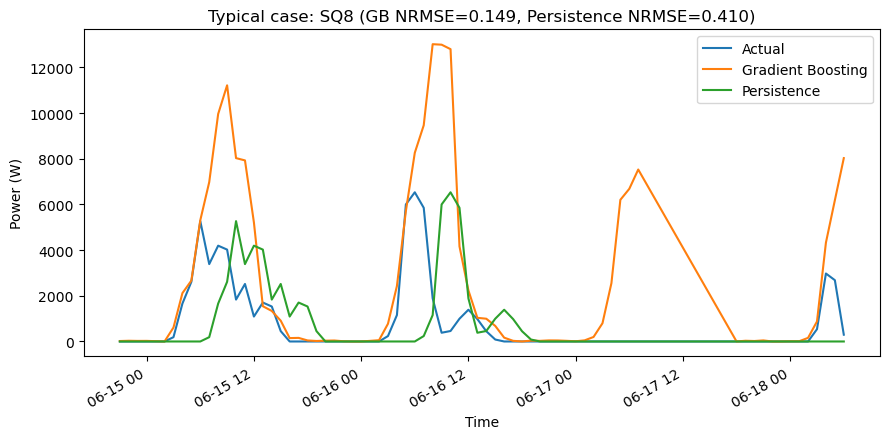

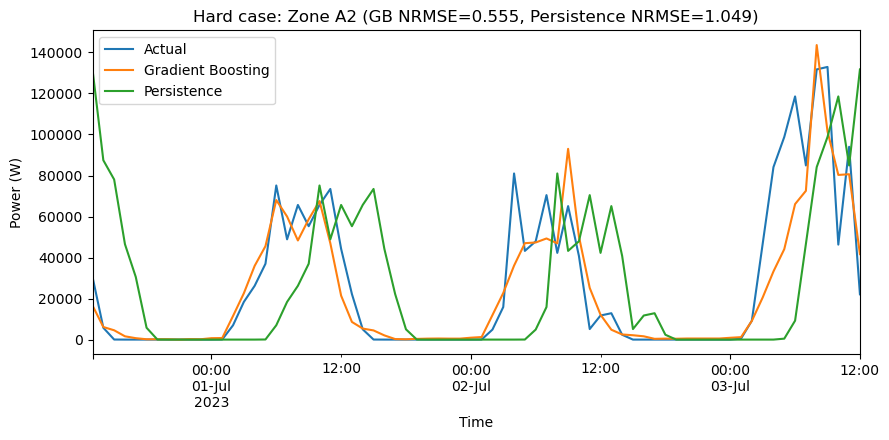

   Site    Case  RMSE_GB_W  RMSE_Persistence_W
    SQ8 typical     3475.1              2107.9
Zone A2    hard    15944.9             42207.3


In [20]:
# AI-assisted (Claude Code): Q1 example time-series plots showing tuned
# Gradient Boosting vs Persistence. Two sites are shown side by side:
# a typical case (site closest to median GB NRMSE) and a hard case
# (Zone A2, a 249.5 kW multi-inverter installation where both models
# degrade — see the LOSO analysis in Section 15.4).

# --- Pick the typical-case site: filtered site whose GB NRMSE is
# closest to the median of GB NRMSE across filtered sites.
gb_rows = (
    results_filtered[results_filtered["model"] == "Gradient Boosting"]
    .set_index("site_id")[["NRMSE_p95"]]
    .rename(columns={"NRMSE_p95": "gb_NRMSE"})
)
persist_rows = (
    persist_df.set_index("site_id")[["NRMSE_p95"]]
    .rename(columns={"NRMSE_p95": "persist_NRMSE"})
)
nrmse_table = gb_rows.join(persist_rows, how="inner")

gb_median = nrmse_table["gb_NRMSE"].median()
nrmse_table["abs_dev_from_median"] = (
    nrmse_table["gb_NRMSE"] - gb_median
).abs()

typical_candidates = [
    sid for sid in nrmse_table.sort_values("abs_dev_from_median").index
    if sid in filtered_site_ids
    and len(site_splits[sid]["test"]) >= steps_per_day * 3
]
if not typical_candidates:
    raise RuntimeError("No eligible typical-case site found for Q1 plot.")
typical_site = str(typical_candidates[0])

# --- Hard-case site: Zone A2 if present, else the filtered site with
# the highest GB NRMSE as a fallback.
if "Zone A2" in filtered_site_ids and len(site_splits["Zone A2"]["test"]) >= steps_per_day * 3:
    hard_site = "Zone A2"
else:
    hard_candidates = [
        sid for sid in nrmse_table.sort_values("gb_NRMSE", ascending=False).index
        if sid in filtered_site_ids
        and len(site_splits[sid]["test"]) >= steps_per_day * 3
    ]
    if not hard_candidates:
        raise RuntimeError("No eligible hard-case site found for Q1 plot.")
    hard_site = str(hard_candidates[0])

print(f"Q1 typical-case site: {typical_site}")
print(f"  GB NRMSE:          {nrmse_table.loc[typical_site, 'gb_NRMSE']:.4f}")
print(f"  Persistence NRMSE: {nrmse_table.loc[typical_site, 'persist_NRMSE']:.4f}")
print(f"Q1 hard-case site: {hard_site}")
print(f"  GB NRMSE:          {nrmse_table.loc[hard_site, 'gb_NRMSE']:.4f}")
print(f"  Persistence NRMSE: {nrmse_table.loc[hard_site, 'persist_NRMSE']:.4f}")


# --- Helper: for a given site, fit tuned GB on its own training data
# and return (plot_df in Watts, RMSE_GB, RMSE_persistence).
def _build_q1_panel(site_id):
    obj = site_splits[site_id]
    train_s = obj["train"]
    test_s = obj["test"]
    rated_W = obj["raw_train"]["rated_power_W"].dropna().iloc[0]

    gb_setting = best_model_settings["Gradient Boosting"]
    gb_pred_pu = fit_predict_model(
        "Gradient Boosting",
        train_s[feature_cols], train_s["y_future"],
        test_s[feature_cols],
        alpha=gb_setting.get("alpha"),
        params=gb_setting.get("params"),
    )

    actual_W = test_s["y_future"] * rated_W
    gb_pred_W = gb_pred_pu * rated_W
    persistence_W = (
        test_s[TARGET_COL].clip(lower=0, upper=CONFIG["PREDICTION_CLIP_MAX"])
        * rated_W
    )

    plot_len = steps_per_day * 3
    plot_idx = actual_W.index[:plot_len]

    panel_df = pd.DataFrame({
        "Actual": actual_W,
        "Gradient Boosting": gb_pred_W,
        "Persistence": persistence_W,
    }).loc[plot_idx].dropna()

    rmse_gb = float(
        np.sqrt(((panel_df["Actual"] - panel_df["Gradient Boosting"]) ** 2).mean())
    )
    rmse_persist = float(
        np.sqrt(((panel_df["Actual"] - panel_df["Persistence"]) ** 2).mean())
    )
    return panel_df, rmse_gb, rmse_persist


typical_df, rmse_gb_typ, rmse_pers_typ = _build_q1_panel(typical_site)
hard_df, rmse_gb_hard, rmse_pers_hard = _build_q1_panel(hard_site)

# --- Figure 1: typical case ---
fig1, ax1 = plt.subplots(figsize=(9, 4.5))
typical_df.plot(ax=ax1)
ax1.set_title(
    f"Typical case: {typical_site} "
    f"(GB NRMSE={nrmse_table.loc[typical_site, 'gb_NRMSE']:.3f}, "
    f"Persistence NRMSE={nrmse_table.loc[typical_site, 'persist_NRMSE']:.3f})"
)
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()

# --- Figure 2: hard case ---
fig2, ax2 = plt.subplots(figsize=(9, 4.5))
hard_df.plot(ax=ax2)
ax2.set_title(
    f"Hard case: {hard_site} "
    f"(GB NRMSE={nrmse_table.loc[hard_site, 'gb_NRMSE']:.3f}, "
    f"Persistence NRMSE={nrmse_table.loc[hard_site, 'persist_NRMSE']:.3f})"
)
ax2.set_xlabel("Time")
ax2.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "Site":                [typical_site, hard_site],
    "Case":                ["typical", "hard"],
    "RMSE_GB_W":           [round(rmse_gb_typ, 1),  round(rmse_gb_hard, 1)],
    "RMSE_Persistence_W":  [round(rmse_pers_typ, 1), round(rmse_pers_hard, 1)],
}).to_string(index=False))


### Feature importances

Impurity-based feature importances are extracted for the tuned Random Forest and Gradient Boosting models on the largest available filtered site. This indicates which predictors the tree-based models relied on most heavily, connecting the model’s internal structure back to the physical drivers of PV generation.

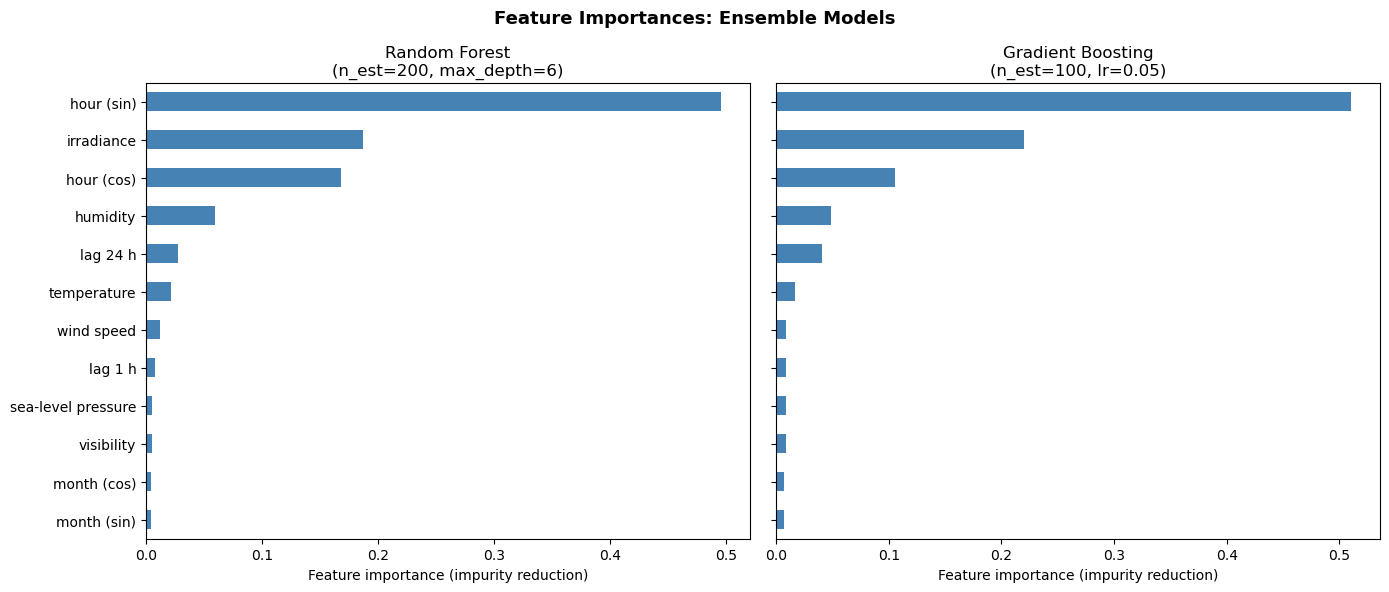

In [21]:
# AI-assisted addition (Claude): feature importance extraction for ensemble models.
# This section shows which predictors the tree-based models relied on most heavily,
# connecting the model's internal structure to the physical system.

def get_feature_importances(model_name, setting, feature_names, site_splits, filtered_ids, config=CONFIG):
    """
    Fit the specified model on every filtered site and return mean feature importances.
    
    Averaging across sites gives a more robust estimate than relying on any single
    site, and matches how NRMSE and win rate are aggregated elsewhere in the pipeline.
    Tree-based models provide importances based on how much each feature reduces the
    loss at each split point (Gini importance / variance reduction).
    """
    importance_rows = []
    
    for site_id in filtered_ids:
        obj = site_splits[site_id]
        train = obj["train"]
        
        # Skip sites with no usable training data after dropping NaNs.
        X_train = train[feature_names].dropna()
        y_train = train["y_future"].loc[X_train.index]
        if len(X_train) < 100:
            continue
        
        model = make_model(model_name, params=setting.get("params"), config=config)
        model.fit(X_train, y_train)
        importance_rows.append(pd.Series(model.feature_importances_, index=feature_names))
    
    if not importance_rows:
        return pd.Series(dtype=float)
    
    # Average the importance vectors across sites.
    importance_df = pd.DataFrame(importance_rows)
    mean_importances = importance_df.mean(axis=0)
    
    return mean_importances.sort_values(ascending=True)


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, model_name in zip(axes, ["Random Forest", "Gradient Boosting"]):
    if model_name not in best_model_settings:
        ax.set_title(f"{model_name} (not available)")
        continue
    
    setting = best_model_settings[model_name]
    importances = get_feature_importances(
        model_name, setting, feature_cols, site_splits, filtered_site_ids
    )
    
    # Show the top 12 most important features to keep the plot readable.
    top_n = importances.tail(12)
    
    # Clean display labels — the underlying column names come from the weather
    # loader and carry redundant prefixes (e.g. temp_temp_degree_celsius).
    rename_map = {
        "hour_sin": "hour (sin)",
        "hour_cos": "hour (cos)",
        "dow_sin": "day of week (sin)",
        "dow_cos": "day of week (cos)",
        "month_sin": "month (sin)",
        "month_cos": "month (cos)",
        "wind_dir_sin": "wind direction (sin)",
        "wind_dir_cos": "wind direction (cos)",
        "irr_irradiance_w_m2": "irradiance",
        "temp_temp_degree_celsius": "temperature",
        "rh_rh": "humidity",
        "wind_wind_speed_m_s": "wind speed",
        "rain_rainfall_mm": "rainfall",
        "vis_vis_km": "visibility",
        "slp_slp_hpa": "sea-level pressure",
        "is_daylight": "daylight",
        "lag_1": "lag 1 h",
        "lag_day": "lag 24 h",
    }
    top_n.index = top_n.index.map(lambda x: rename_map.get(x, x))
    
    top_n.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Feature importance (impurity reduction)")
    ax.set_title(f"{model_name}\n({setting['label']})")

plt.suptitle("Feature Importances: Ensemble Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 15. Q2 — Cross-site generalisation

The earlier sections answered the first part of the assignment brief by training and evaluating one model per PV installation. This section addresses the second part of the brief: how well a single model can forecast PV output at sites it has never seen during training, using static metadata about each installation alongside meteorological inputs.

Two complementary holdout designs are used. A random 80/20 site holdout sets aside 20% of the eligible sites as a held-out test group and pools the rest into a single training set. A leave-one-site-out spot check then re-runs the experiment on a small number of individually chosen sites, selected to span the rated-power range, so the headline 80/20 result is not driven by one fortunate split.

Two feature variants are run on identical splits and identical models so the contrast is clean:

- **Variant A — metadata + history.** Uses the full feature set including the lagged target features `lag_1` and `lag_day`. This represents a deployment scenario in which a new site has been instrumented for long enough to provide its own short-term history, but no model has been trained specifically for it.
- **Variant B — metadata only.** Drops the lagged target features. This is the harder, more honest cross-site forecasting task: the model has never seen this installation and has no recent power readings from it. Performance here measures how much can be predicted from metadata, calendar, and weather alone.

Within every site the chronological train/test split from Section 8 is preserved, so no future observation from any site is used for training. The pooled scaler is fit on training-site rows only, which keeps held-out site distributions out of model construction. Model classes are restricted to Linear, Ridge, Random Forest, and Gradient Boosting, reusing the hyperparameter settings selected during the per-site inner-validation sweep so the algorithm is held constant between the per-site and cross-site comparisons. MLP is omitted because the pooled dataset is roughly fifty times larger than a single-site dataset and training time becomes prohibitive.

In [22]:
# AI-assisted (Claude Code): cross-site generalisation infrastructure.
# Defines the configuration, dataset builders, and pooled training loop
# reused by both the 80/20 experiment and the leave-one-site-out check.

CROSS_SITE_CONFIG = {
    "HOLDOUT_FRAC": 0.20,
    "RANDOM_STATE": 42,
    "N_LOSO_SITES": 3,
    "MODELS": ["Linear", "Ridge", "Random Forest", "Gradient Boosting"],
    "METADATA_COLS": [
        "tilt_deg", "azimuth_sin", "azimuth_cos", "altitude_m",
        "rated_power_W", "has_optimizer", "mixed_orientation", "connection_year",
    ],
}


def has_complete_metadata(splits: dict, sid: str, metadata_cols) -> bool:
    """Return True if the site has at least one non-null value for every metadata column."""
    train = splits[sid]["train"]
    return all(train[c].notna().any() for c in metadata_cols)


def build_pooled_frame(
    site_ids,
    splits: dict,
    *,
    split: str,
    use_lags: bool,
    metadata_cols,
    base_features,
):
    """
    Concatenate per-site supervised tables into one pooled dataframe.

    Parameters
    ----------
    site_ids : iterable of str
        Sites whose rows should be included in the pooled dataset.
    splits : dict
        The site_splits dictionary built in Section 8.
    split : {"train", "test"}
        Which chronological segment to take from each site.
    use_lags : bool
        If False, drop the lagged target features so that the model relies
        only on calendar, weather, and site-level metadata.
    metadata_cols : list[str]
        Static per-site columns appended to every row.
    base_features : list[str]
        Time-series feature list reused from the per-site pipeline.

    Returns
    -------
    X : pd.DataFrame
        Pooled feature matrix.
    y : pd.Series
        Pooled target vector.
    site_index : pd.Series
        Site id for each pooled row, used for per-site evaluation.
    feature_list : list[str]
        Final ordered feature columns used by the model.
    """
    feature_list = [c for c in base_features if (use_lags or c not in {"lag_1", "lag_day"})]
    feature_list = feature_list + list(metadata_cols)

    frames = []
    for sid in site_ids:
        df = splits[sid][split]
        df_clean = df.dropna(subset=feature_list + ["y_future"])
        if df_clean.empty:
            continue
        block = df_clean[feature_list + ["y_future"]].copy()
        block["site_id"] = sid
        frames.append(block)

    if not frames:
        empty = pd.DataFrame(columns=feature_list)
        return empty, pd.Series(dtype=float), pd.Series(dtype=object), feature_list

    pooled = pd.concat(frames, axis=0)
    return pooled[feature_list], pooled["y_future"], pooled["site_id"], feature_list


def evaluate_pooled_on_sites(
    train_sites,
    eval_sites,
    splits: dict,
    *,
    use_lags: bool,
    models,
    model_settings: dict,
    metadata_cols,
    base_features,
    config=CONFIG,
) -> pd.DataFrame:
    """
    Train each pooled model once on `train_sites` and evaluate on every site
    in `eval_sites` using that site's chronological test segment.

    Each held-out site is scored independently against its own training-set
    p95, matching the normalisation used in the per-site pipeline. The pooled
    scaler is fit on training-site rows only, so no information from a held-out
    site can leak into model construction.
    """
    X_train, y_train, _, feature_list = build_pooled_frame(
        train_sites, splits,
        split="train",
        use_lags=use_lags,
        metadata_cols=metadata_cols,
        base_features=base_features,
    )
    if X_train.empty:
        return pd.DataFrame()

    rows = []
    for model_name in models:
        setting = model_settings.get(model_name, {})

        # Pool every eval site's test rows so the model is fit once per
        # variant and the same scaler is shared across all held-out sites.
        eval_blocks = []
        for sid in eval_sites:
            test_clean = splits[sid]["test"].dropna(subset=feature_list + ["y_future"])
            if test_clean.empty:
                continue
            p95 = compute_p95_train(splits[sid]["train"]["y_future"])
            if p95 == 0 or np.isnan(p95):
                continue
            block = test_clean[feature_list + ["y_future"]].copy()
            block["site_id"] = sid
            block["__p95"] = p95
            eval_blocks.append(block)

        if not eval_blocks:
            continue

        eval_pool = pd.concat(eval_blocks, axis=0).reset_index(drop=True)
        X_test = eval_pool[feature_list]
        y_test = eval_pool["y_future"]

        pred = fit_predict_model(
            model_name, X_train, y_train, X_test,
            alpha=setting.get("alpha"),
            params=setting.get("params"),
            config=config,
        )
        eval_pool["__pred"] = pred.values

        for sid, group in eval_pool.groupby("site_id", sort=False):
            yt = group["y_future"]
            yp = group["__pred"]
            p95 = group["__p95"].iloc[0]
            rows.append({
                "site_id": sid,
                "model": model_name,
                "RMSE": rmse(yt, yp),
                "MAE": mae(yt, yp),
                "NRMSE_p95": nrmse_p95(yt, yp, p95),
                "NMAE_p95": nmae_p95(yt, yp, p95),
                "n_test": len(yt),
            })

    return pd.DataFrame(rows)


def select_loso_sites(site_ids, splits: dict, n: int):
    """
    Pick `n` sites for the leave-one-site-out spot check.

    Sites are ordered by rated power and the smallest, largest, and median
    installations are selected so the spot check spans the capacity range
    rather than three near-duplicates.
    """
    rated = pd.Series({
        sid: splits[sid]["raw_train"]["rated_power_W"].dropna().iloc[0]
        for sid in site_ids
        if splits[sid]["raw_train"]["rated_power_W"].notna().any()
    }).sort_values()
    if rated.empty:
        return []
    picks = [rated.index[0], rated.index[-1]]
    if n >= 3 and len(rated) >= 3:
        picks.append(rated.index[len(rated) // 2])
    return list(dict.fromkeys(picks))[:n]


# Restrict the experiment to filtered sites with complete metadata so no row
# is silently dropped from the pooled training set during model fitting.
cross_site_eligible = [
    sid for sid in filtered_site_ids
    if has_complete_metadata(site_splits, sid, CROSS_SITE_CONFIG["METADATA_COLS"])
]
print(
    f"Eligible sites for cross-site experiment: {len(cross_site_eligible)} / {len(filtered_site_ids)}"
)

dropped = [s for s in filtered_site_ids if s not in cross_site_eligible]
if dropped:
    print(f"Dropped due to incomplete metadata: {dropped}")


Eligible sites for cross-site experiment: 40 / 57
Dropped due to incomplete metadata: ['Library', 'SQ Apartment37-48 Flexible PV', 'SQ11', 'SQ12', 'SQ13', 'SQ14', 'SQ15', 'SQ19', 'SQ567 Flexible PV', 'SQ8', 'Shaw Auditorium', 'UG Hall7 Flexible PV', 'Zone D', 'Zone J1', 'Zone J2', 'Zone L1 (Station 1)', 'Zone L1(Station 2)']


### 15.1 Random 80/20 site holdout

Sites are split at the installation level rather than at the timestamp level: 80% of the eligible sites form the pooled training group and the remaining 20% are held out entirely. The split is purely random with a fixed seed so that the result is reproducible across runs without making the holdout reflect any particular metadata characteristic. Within every site the chronological train/test boundary from Section 8 is preserved, which guarantees that no future observation is used for fitting and that held-out sites contribute zero rows to the pooled training set.

In [23]:
rng = np.random.default_rng(CROSS_SITE_CONFIG["RANDOM_STATE"])
shuffled_sites = list(cross_site_eligible)
rng.shuffle(shuffled_sites)

n_holdout = max(1, int(round(len(shuffled_sites) * CROSS_SITE_CONFIG["HOLDOUT_FRAC"])))
heldout_sites = sorted(shuffled_sites[:n_holdout])
train_pool_sites = sorted(shuffled_sites[n_holdout:])

print(f"Pooled training sites: {len(train_pool_sites)}")
print(f"Held-out sites:        {len(heldout_sites)}")
print(f"Held-out site ids:     {heldout_sites}")

# Leakage check: confirm no site appears in both groups.
assert set(train_pool_sites).isdisjoint(heldout_sites), "Site leak between train and held-out groups"
print("\u2713 No site overlap between training pool and held-out group.")


Pooled training sites: 32
Held-out sites:        8
Held-out site ids:     ['LSK South', 'S H Ho Sports Hall', 'SQ Apartment13-24', 'SQ10', 'SQ17', 'Wong Check She Research Centre', 'Zone A6', 'Zone L2']
✓ No site overlap between training pool and held-out group.


### 15.2 Pooled training: metadata + history vs metadata only

Both feature variants are evaluated on identical site splits using identical models and identical hyperparameter settings. The only difference between the two runs is whether the lagged target features are present, which isolates the contribution of short-term site history to the cross-site forecast. Each model is fit once on the full pooled training set per variant and predictions for every held-out site are generated from that single fit, so the comparison across sites uses the same fitted estimator.

In [24]:
cross_site_results_frames = []
for variant_label, use_lags in [("metadata + history", True), ("metadata only", False)]:
    df_variant = evaluate_pooled_on_sites(
        train_pool_sites,
        heldout_sites,
        site_splits,
        use_lags=use_lags,
        models=CROSS_SITE_CONFIG["MODELS"],
        model_settings=best_model_settings,
        metadata_cols=CROSS_SITE_CONFIG["METADATA_COLS"],
        base_features=feature_cols,
    )
    df_variant["variant"] = variant_label
    cross_site_results_frames.append(df_variant)

cross_site_results = pd.concat(cross_site_results_frames, ignore_index=True)

cross_site_summary = (
    cross_site_results
    .groupby(["variant", "model"], sort=False)
    .agg(
        mean_NRMSE_p95=("NRMSE_p95", "mean"),
        median_NRMSE_p95=("NRMSE_p95", "median"),
        mean_NMAE_p95=("NMAE_p95", "mean"),
    )
    .round(4)
    .reset_index()
)
print("Cross-site held-out NRMSE_p95 by variant and model:")
print(cross_site_summary)


Cross-site held-out NRMSE_p95 by variant and model:
              variant              model  mean_NRMSE_p95  median_NRMSE_p95  \
0  metadata + history             Linear          0.2276            0.2101   
1  metadata + history              Ridge          0.2275            0.2101   
2  metadata + history      Random Forest          0.1858            0.1657   
3  metadata + history  Gradient Boosting          0.1679            0.1541   
4       metadata only             Linear          0.2311            0.2239   
5       metadata only              Ridge          0.2310            0.2240   
6       metadata only      Random Forest          0.1866            0.1674   
7       metadata only  Gradient Boosting          0.1694            0.1582   

   mean_NMAE_p95  
0         0.1605  
1         0.1605  
2         0.0969  
3         0.0917  
4         0.1621  
5         0.1621  
6         0.0970  
7         0.0926  


### 15.3 Comparison against persistence and within-site models

For each held-out site the cross-site NRMSE is contrasted with two reference points: the persistence baseline computed in Section 11 and the within-site model trained only on that site's own history in Section 12. The persistence comparison shows whether the cross-site model has learned anything useful from metadata and weather, and the within-site comparison quantifies the cost of not having site-specific training data, which is the headline result of this experiment.

Held-out site comparison (mean NRMSE_p95):
              variant              model  cross_site_NRMSE  within_site_NRMSE  \
0  metadata + history             Linear            0.2276             0.2117   
1  metadata + history              Ridge            0.2275             0.2112   
2  metadata + history      Random Forest            0.1858             0.1669   
3  metadata + history  Gradient Boosting            0.1679             0.1590   
4       metadata only             Linear            0.2311             0.2117   
5       metadata only              Ridge            0.2310             0.2112   
6       metadata only      Random Forest            0.1866             0.1669   
7       metadata only  Gradient Boosting            0.1694             0.1590   

   persistence_NRMSE  mean_cost_vs_within_site  
0             0.3956                    0.0159  
1             0.3956                    0.0163  
2             0.3956                    0.0190  
3             0.3956           

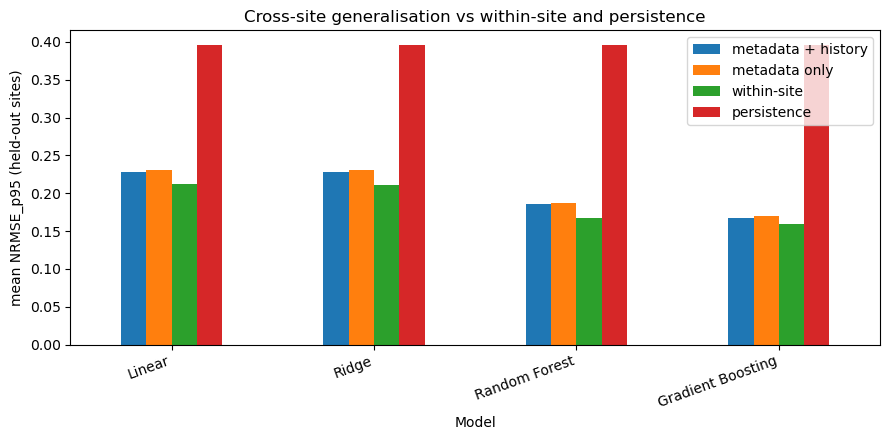

In [25]:
# Pull persistence and within-site references for the same held-out sites.
persistence_ref = (
    persist_df[persist_df["site_id"].isin(heldout_sites)]
    [["site_id", "NRMSE_p95"]]
    .rename(columns={"NRMSE_p95": "persistence_NRMSE_p95"})
)
within_ref = (
    results_df[
        results_df["site_id"].isin(heldout_sites)
        & results_df["model"].isin(CROSS_SITE_CONFIG["MODELS"])
    ]
    [["site_id", "model", "NRMSE_p95"]]
    .rename(columns={"NRMSE_p95": "within_site_NRMSE_p95"})
)

comparison = (
    cross_site_results.merge(persistence_ref, on="site_id", how="left")
    .merge(within_ref, on=["site_id", "model"], how="left")
)
comparison["cost_of_no_site_data"] = (
    comparison["NRMSE_p95"] - comparison["within_site_NRMSE_p95"]
)

comparison_summary = (
    comparison
    .groupby(["variant", "model"], sort=False)
    .agg(
        cross_site_NRMSE=("NRMSE_p95", "mean"),
        within_site_NRMSE=("within_site_NRMSE_p95", "mean"),
        persistence_NRMSE=("persistence_NRMSE_p95", "mean"),
        mean_cost_vs_within_site=("cost_of_no_site_data", "mean"),
    )
    .round(4)
    .reset_index()
)
print("Held-out site comparison (mean NRMSE_p95):")
print(comparison_summary)

# Bar chart: cross-site (per variant) alongside within-site and persistence.
model_order_local = [m for m in CONFIG["MODEL_ORDER"] if m in CROSS_SITE_CONFIG["MODELS"]]
plot_df = comparison_summary.pivot(index="model", columns="variant", values="cross_site_NRMSE")
plot_df = plot_df.reindex(model_order_local)
plot_df["within-site"] = (
    comparison_summary.groupby("model")["within_site_NRMSE"].first().reindex(model_order_local)
)
plot_df["persistence"] = (
    comparison_summary.groupby("model")["persistence_NRMSE"].first().reindex(model_order_local)
)

ax = plot_df.plot(kind="bar", figsize=(9, 4.5))
ax.set_ylabel("mean NRMSE_p95 (held-out sites)")
ax.set_xlabel("Model")
ax.set_title("Cross-site generalisation vs within-site and persistence")
plt.xticks(rotation=20, ha="right")
plt.legend(title="", loc="best")
plt.tight_layout()
plt.show()


### Q2 example: unseen-site forecast

The plot below shows a three-day window from one held-out site’s test set. The pooled Gradient Boosting model has never seen any data from this installation during training, yet its forecast tracks the true power output while persistence visibly lags.

Q2 example site: LSK South


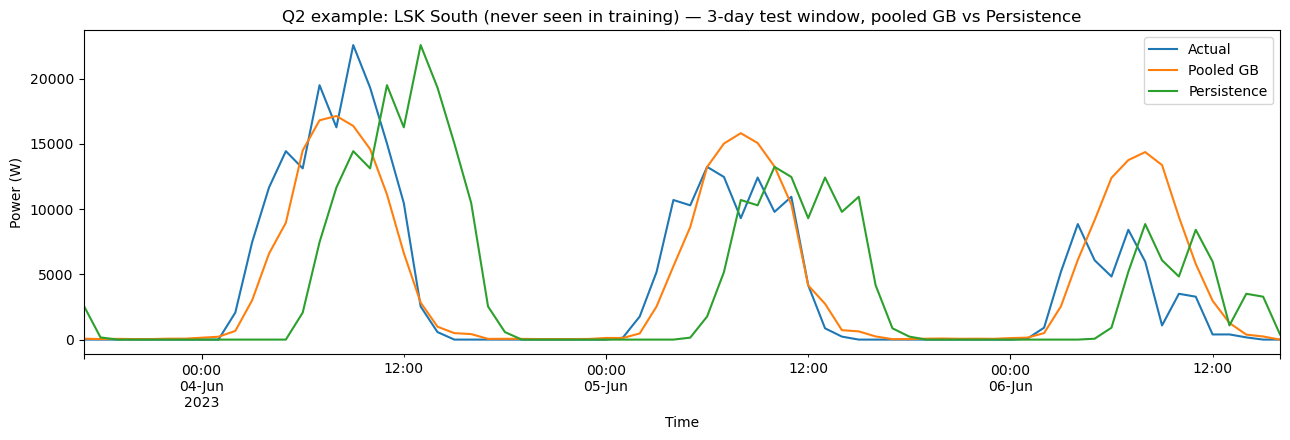

                   Model  RMSE_W
Pooled Gradient Boosting  3047.1
             Persistence  6536.8


In [26]:
# AI-assisted (Claude Code): Q2 example time-series plot showing pooled
# cross-site Gradient Boosting vs Persistence on a held-out site.

# Build the pooled training set (metadata + history variant) for refitting.
X_pool_train, y_pool_train, _, pool_features = build_pooled_frame(
    train_pool_sites, site_splits,
    split="train", use_lags=True,
    metadata_cols=CROSS_SITE_CONFIG["METADATA_COLS"],
    base_features=feature_cols,
)

# Pick the first held-out site with at least 3 days of test data.
q2_site_id = None
for sid in heldout_sites:
    test_clean = site_splits[sid]["test"].dropna(subset=pool_features + ["y_future"])
    if len(test_clean) >= steps_per_day * 3:
        q2_site_id = sid
        break

print(f"Q2 example site: {q2_site_id}")

obj_q2 = site_splits[q2_site_id]
test_q2 = obj_q2["test"].dropna(subset=pool_features + ["y_future"])
rated_W_q2 = obj_q2["raw_train"]["rated_power_W"].dropna().iloc[0]

# Fit pooled GB on all training sites and predict on this held-out site.
gb_setting = best_model_settings["Gradient Boosting"]
gb_pred_pu = fit_predict_model(
    "Gradient Boosting", X_pool_train, y_pool_train,
    test_q2[pool_features],
    alpha=gb_setting.get("alpha"), params=gb_setting.get("params"),
)

# Convert to Watts.
actual_W_q2 = test_q2["y_future"] * rated_W_q2
gb_pred_W_q2 = gb_pred_pu * rated_W_q2
persistence_W_q2 = test_q2[TARGET_COL].clip(lower=0, upper=CONFIG["PREDICTION_CLIP_MAX"]) * rated_W_q2

# Select a 3-day window from the start of the test set.
plot_len = steps_per_day * 3
plot_idx_q2 = actual_W_q2.index[:plot_len]

plot_df_q2 = pd.DataFrame({
    "Actual": actual_W_q2,
    "Pooled GB": gb_pred_W_q2,
    "Persistence": persistence_W_q2,
}).loc[plot_idx_q2].dropna()

ax = plot_df_q2.plot(figsize=(13, 4.5))
ax.set_title(
    f"Q2 example: {q2_site_id} (never seen in training) "
    f"\u2014 3-day test window, pooled GB vs Persistence"
)
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()

# RMSE on the plotted window.
rmse_gb_q2 = np.sqrt(((plot_df_q2["Actual"] - plot_df_q2["Pooled GB"]) ** 2).mean())
rmse_persist_q2 = np.sqrt(((plot_df_q2["Actual"] - plot_df_q2["Persistence"]) ** 2).mean())
print(pd.DataFrame({
    "Model": ["Pooled Gradient Boosting", "Persistence"],
    "RMSE_W": [round(rmse_gb_q2, 1), round(rmse_persist_q2, 1)],
}).to_string(index=False))


### 15.4 Leave-one-site-out spot check

The 80/20 holdout averages over a particular random partition. To probe whether cross-site performance depends on which sites are held out, a small number of sites are held out individually and the model is retrained on every other eligible site. Sites are selected to span the rated-power range (smallest, largest, and median installation) so the spot check exercises different regions of the metadata distribution. Per-site results are reported alongside the site's metadata so unusually hard or easy installations can be related to physical characteristics. This step is more expensive than the headline experiment because the pooled model is refit once per held-out site.

In [27]:
loso_sites = select_loso_sites(
    cross_site_eligible, site_splits, CROSS_SITE_CONFIG["N_LOSO_SITES"]
)
print(f"LOSO spot-check sites: {loso_sites}")

loso_frames = []
for held in loso_sites:
    train_sites_loso = [s for s in cross_site_eligible if s != held]
    for variant_label, use_lags in [("metadata + history", True), ("metadata only", False)]:
        df = evaluate_pooled_on_sites(
            train_sites_loso,
            [held],
            site_splits,
            use_lags=use_lags,
            models=CROSS_SITE_CONFIG["MODELS"],
            model_settings=best_model_settings,
            metadata_cols=CROSS_SITE_CONFIG["METADATA_COLS"],
            base_features=feature_cols,
        )
        df["variant"] = variant_label
        loso_frames.append(df)

loso_results = pd.concat(loso_frames, ignore_index=True)

# Attach metadata for each held-out site so unusual installations are easy to spot.
metadata_lookup_rows = []
for sid in loso_sites:
    train = site_splits[sid]["raw_train"]
    metadata_lookup_rows.append({
        "site_id": sid,
        "rated_power_W": train["rated_power_W"].dropna().iloc[0] if train["rated_power_W"].notna().any() else np.nan,
        "tilt_deg": train["tilt_deg"].dropna().iloc[0] if train["tilt_deg"].notna().any() else np.nan,
        "altitude_m": train["altitude_m"].dropna().iloc[0] if train["altitude_m"].notna().any() else np.nan,
        "mixed_orientation": int(train["mixed_orientation"].dropna().iloc[0]) if train["mixed_orientation"].notna().any() else np.nan,
        "has_optimizer": int(train["has_optimizer"].dropna().iloc[0]) if train["has_optimizer"].notna().any() else np.nan,
    })
loso_metadata = pd.DataFrame(metadata_lookup_rows)

loso_table = (
    loso_results.merge(loso_metadata, on="site_id", how="left")
    [["site_id", "variant", "model", "NRMSE_p95", "NMAE_p95",
      "rated_power_W", "tilt_deg", "altitude_m", "mixed_orientation", "has_optimizer"]]
    .sort_values(["site_id", "variant", "model"])
    .round(4)
)
print("\nLeave-one-site-out per-site results with metadata:")
print(loso_table.to_string(index=False))

# Sanity check — per-site persistence NRMSE for the three LOSO rows.
for sid in loso_sites:
    row = persist_df[persist_df["site_id"] == sid]
    if not row.empty:
        print(f"{sid}: persistence NRMSE = {row['NRMSE_p95'].iloc[0]:.4f}")


LOSO spot-check sites: ['UG Hall2 RF', 'Zone A2', 'UG Hall7']

Leave-one-site-out per-site results with metadata:
    site_id            variant             model  NRMSE_p95  NMAE_p95  rated_power_W  tilt_deg  altitude_m  mixed_orientation  has_optimizer
UG Hall2 RF metadata + history Gradient Boosting     0.1248    0.0675         8000.0       0.0        22.0                  0              1
UG Hall2 RF metadata + history            Linear     0.1836    0.1331         8000.0       0.0        22.0                  0              1
UG Hall2 RF metadata + history     Random Forest     0.1461    0.0772         8000.0       0.0        22.0                  0              1
UG Hall2 RF metadata + history             Ridge     0.1836    0.1331         8000.0       0.0        22.0                  0              1
UG Hall2 RF      metadata only Gradient Boosting     0.1292    0.0704         8000.0       0.0        22.0                  0              1
UG Hall2 RF      metadata only          

## Appendix A: Exploratory site overlay plots

These plots provide a quick visual check of the raw data for selected sites. The first plot overlays PV power output and irradiance on a shared time axis to confirm that the two signals track each other as expected physically. The second plot normalises both quantities to a common 0–1 scale so their shapes can be compared more directly.

This is useful for spotting data issues such as misaligned timestamps, missing irradiance periods, or sites where power does not follow the expected solar pattern.

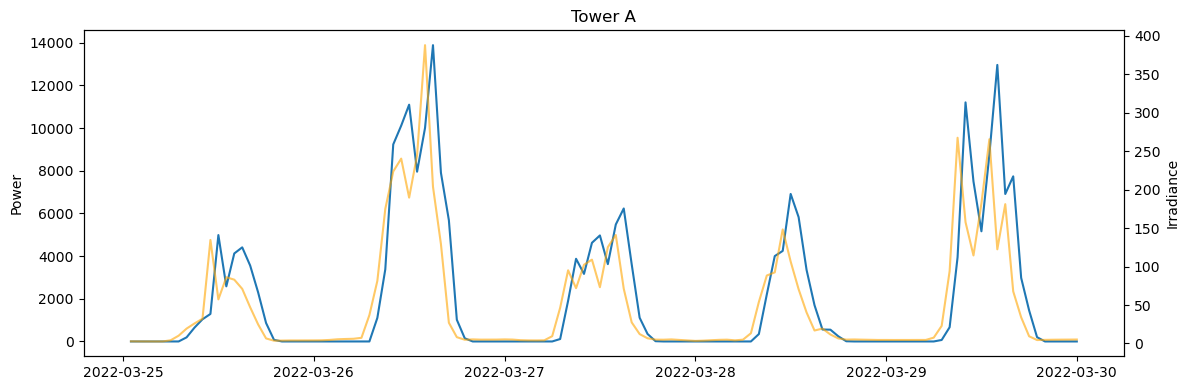

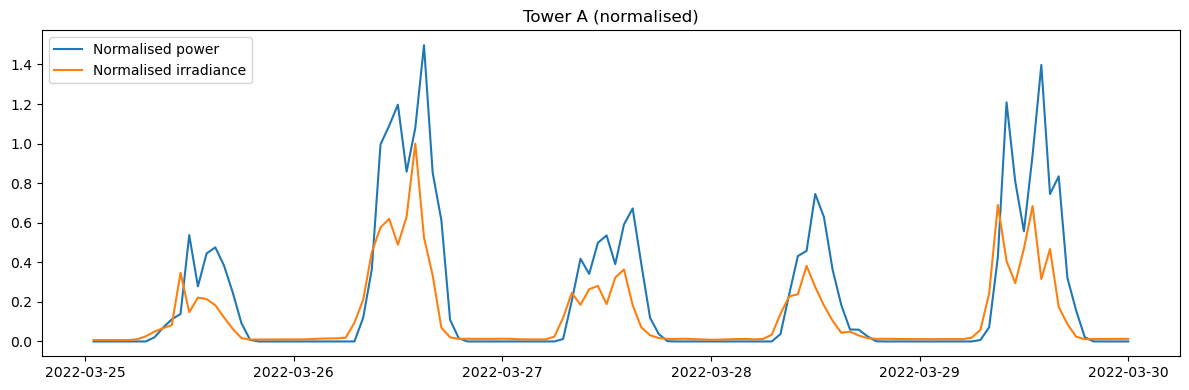

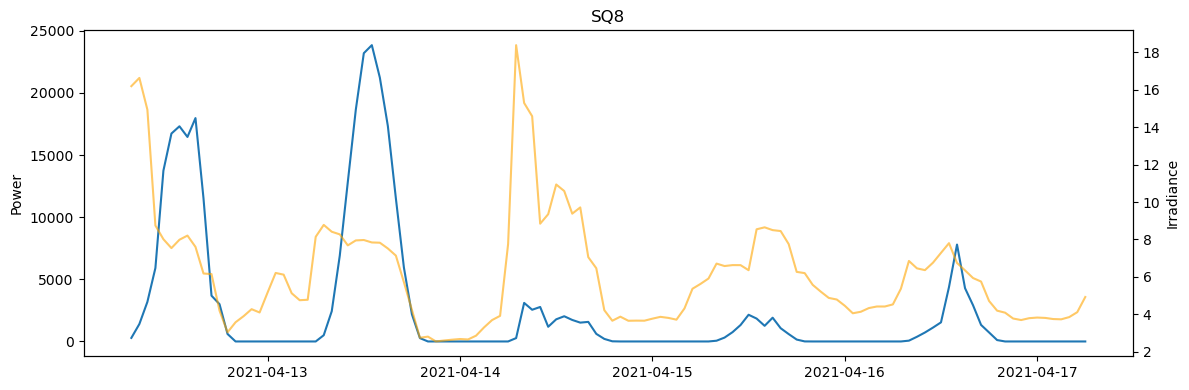

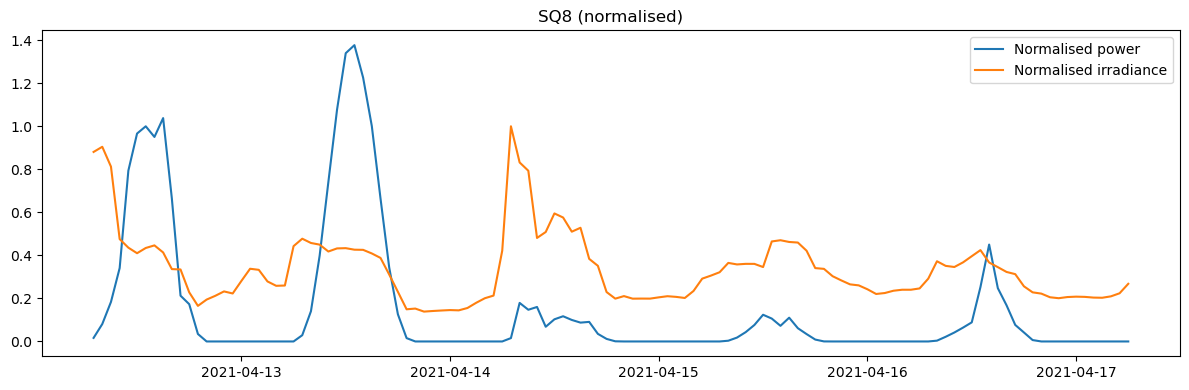

In [28]:
# Exploratory overlay plots for selected sites.

def plot_site_overlay(site_name, days=5):
    """Plot raw power and irradiance on a dual-axis chart for visual inspection."""
    df = pv_all_sites_weather[pv_all_sites_weather["site_id"] == site_name].copy()
    df = df.sort_index().iloc[:steps_per_day * days]

    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(df.index, df["power_W"], label="Power (W)")
    ax1.set_ylabel("Power")

    # Overlay irradiance on a second y-axis so the two quantities can be
    # compared visually despite having very different units and scales.
    if "irr_irradiance_w_m2" in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df.index, df["irr_irradiance_w_m2"], color="orange", alpha=0.6, label="Irradiance")
        ax2.set_ylabel("Irradiance")

    plt.title(site_name)
    plt.tight_layout()
    plt.show()


def plot_normalised(site_name, days=5):
    """Plot power and irradiance on a common 0–1 scale for shape comparison."""
    df = pv_all_sites_weather[pv_all_sites_weather["site_id"] == site_name].copy()
    df = df.sort_index().iloc[:steps_per_day * days]

    # Normalise power by its 95th percentile and irradiance by its maximum,
    # bringing both onto a roughly 0–1 range for visual comparison.
    scale = df["power_W"].quantile(0.95)
    df["power_norm"] = df["power_W"] / scale

    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(df.index, df["power_norm"], label="Normalised power")
    if "irr_irradiance_w_m2" in df.columns:
        ax.plot(df.index, df["irr_irradiance_w_m2"] / df["irr_irradiance_w_m2"].max(), label="Normalised irradiance")
    ax.legend()
    plt.title(f"{site_name} (normalised)")
    plt.tight_layout()
    plt.show()

# Plot a couple of example sites to check the data visually.
for site in ["Tower A", "SQ8"]:
    if site in pv_all_sites_weather["site_id"].unique():
        plot_site_overlay(site)
        plot_normalised(site)


## Appendix B: Single-site baselines (persistence / same-time-yesterday / rolling mean)

This appendix evaluates three simple baseline forecasts on the default single site before any machine learning models are introduced. The baselines are: persistence (predict the most recent value), same-time-yesterday (predict the value from 24 hours ago), and a rolling mean over the previous few hours. These provide a reference level of accuracy that any more complex model should aim to beat.

Note: this section uses the `steps_per_day` variable to construct the same-time-yesterday lag and to slice the plot window. Make sure this matches the resampled hourly cadence (24 steps per day).

                                               MAE         RMSE
Model                                                          
Persistence (t-1)                      1892.900669  3479.510349
Same time yesterday (t-steps_per_day)  2052.396236  4575.429269
Rolling mean 3h                        3267.217132  5556.410164


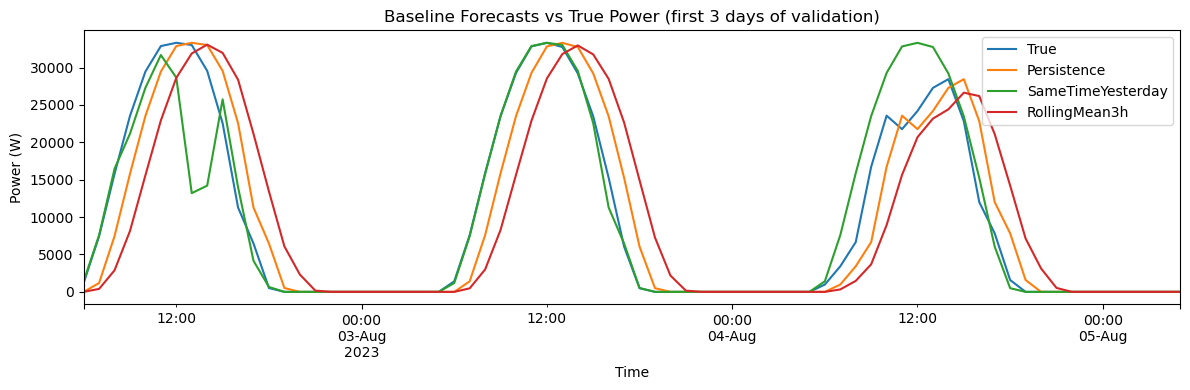

In [29]:
# Single-site baseline models on the default site.
pv_single = pv.copy()

# Chronological train/validation split.
n = len(pv_single)
split_idx = int(n * CONFIG["TRAIN_FRAC"])
train = pv_single.iloc[:split_idx]
val = pv_single.iloc[split_idx:]

y_val = val["power_W"]
series = pv_single["power_W"]

# Three naive baselines, each using only past information:
# - Persistence: power stays the same as the previous timestep.
# - Same-time-yesterday: power repeats the value from exactly one day ago.
# - Rolling mean: smoothed average of the last few timesteps.
pred_persistence = series.shift(1)
pred_same_time = series.shift(steps_per_day)
pred_roll = series.shift(1).rolling(window=CONFIG["ROLLING_K"], min_periods=CONFIG["ROLLING_K"]).mean()


def score_baseline(y_true, y_pred):
    """Compute MAE and RMSE between true and predicted values, aligning on common indices."""
    aligned = pd.concat([y_true, y_pred.loc[y_true.index]], axis=1, keys=["y", "yhat"]).dropna()
    err = aligned["y"] - aligned["yhat"]
    mae = err.abs().mean()
    rmse_v = np.sqrt((err ** 2).mean())
    return mae, rmse_v

rows = []
for name, pred in [
    ("Persistence (t-1)", pred_persistence),
    ("Same time yesterday (t-steps_per_day)", pred_same_time),
    ("Rolling mean 3h", pred_roll),
]:
    mae, rmse_v = score_baseline(y_val, pred)
    rows.append({"Model": name, "MAE": mae, "RMSE": rmse_v})

baseline_results = pd.DataFrame(rows).set_index("Model").sort_values("RMSE")
print(baseline_results)

# Plot the first 3 days of validation to visually compare each baseline against truth.
plot_len = steps_per_day * 3
plot_index = y_val.index[:plot_len]
plot_df = pd.DataFrame({
    "True": y_val,
    "Persistence": pred_persistence,
    "SameTimeYesterday": pred_same_time,
    "RollingMean3h": pred_roll,
}).loc[plot_index].dropna()

ax = plot_df.plot(figsize=(12, 4))
ax.set_title("Baseline Forecasts vs True Power (first 3 days of validation)")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()


## Appendix C: Single-site Linear Regression with lag features

This appendix fits a simple Linear Regression model on the default single site using three hand-crafted features: the previous timestep's power (lag_1), the power from the same time yesterday (lag_day), and the hour of day. This tests whether even a minimal supervised model can improve on the naive baselines from the previous appendix, and provides a stepping stone towards the more comprehensive multi-site pipeline in the main analysis.

                                           MAE         RMSE
Best baseline (Persistence (t-1))  1892.900669  3479.510349
Linear Regression                  1808.467868  2953.566911


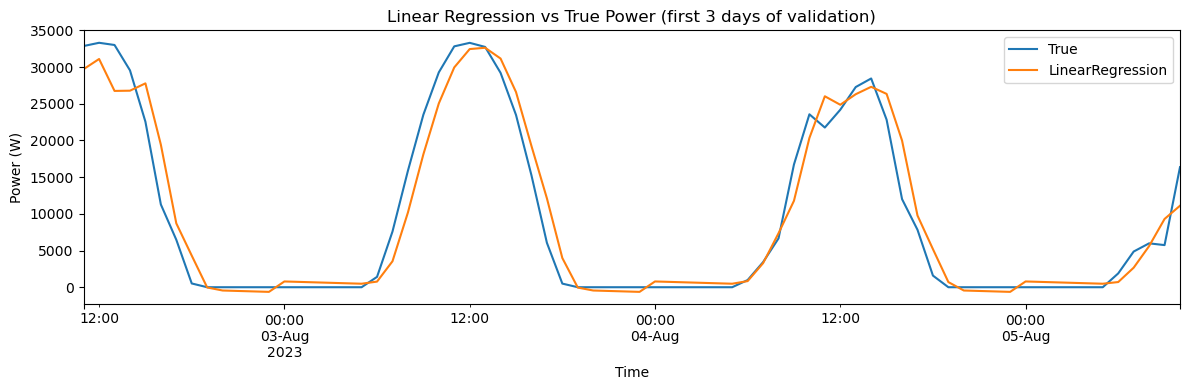

In [30]:
from sklearn.linear_model import LinearRegression

# Build a simple supervised-learning table with three features:
# lag_1 (previous timestep), lag_day (same hour yesterday), and hour of day.
supervised = pd.DataFrame({
    "power_W": pv_single["power_W"],
    "lag_1": pv_single["power_W"].shift(1),
    "lag_day": pv_single["power_W"].shift(steps_per_day),
    "hour": pv_single.index.hour,
}).dropna()

# Chronological split — same fraction as the main pipeline.
split_idx = int(len(supervised) * CONFIG["TRAIN_FRAC"])
train_ml = supervised.iloc[:split_idx]
val_ml = supervised.iloc[split_idx:]

X_train = train_ml[["lag_1", "lag_day", "hour"]]
y_train = train_ml["power_W"]
X_val = val_ml[["lag_1", "lag_day", "hour"]]
y_val_ml = val_ml["power_W"]

# Fit and predict.
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = pd.Series(lr.predict(X_val), index=X_val.index, name="LR_pred")

err = y_val_ml - pred_lr
mae = err.abs().mean()
rmse_v = np.sqrt((err ** 2).mean())

# Compare against the best naive baseline from the previous appendix.
best_baseline = baseline_results.iloc[0]
compare = pd.DataFrame({
    "MAE": {
        f"Best baseline ({baseline_results.index[0]})": best_baseline["MAE"],
        "Linear Regression": mae,
    },
    "RMSE": {
        f"Best baseline ({baseline_results.index[0]})": best_baseline["RMSE"],
        "Linear Regression": rmse_v,
    },
})
print(compare)

# Plot first 3 days of validation
plot_len = steps_per_day * 3
plot_index = y_val_ml.index[:plot_len]
plot_df = pd.DataFrame({
    "True": y_val_ml,
    "LinearRegression": pred_lr,
}).loc[plot_index].dropna()

ax = plot_df.plot(figsize=(12, 4))
ax.set_title("Linear Regression vs True Power (first 3 days of validation)")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()


## Appendix D: H-step ahead (H=4) with baselines and regression models

This appendix extends the single-site analysis to a multi-step-ahead forecasting task. Instead of predicting the next timestep, the target is now the power output H=4 hours into the future. Three naive baselines are compared against Linear Regression, Ridge, Decision Tree, Random Forest, Gradient Boosting, and MLP to show how forecast difficulty increases with the prediction horizon, and whether the learned models still outperform simple heuristics when the gap between input and target is larger. Hyperparameters are taken from the best settings selected during the multi-site inner-validation sweep in Section 12.

                             MAE          RMSE
Model                                         
Gradient Boosting    2135.497846   4074.752567
Random Forest        2172.288299   4183.430423
Decision Tree        2234.291626   4318.396025
Linear               4293.092099   6527.813103
Ridge                4318.949682   6556.535007
MLP                  4683.367927   7112.616073
Persistence (y(t))   6080.615924   9790.148591
Same time yesterday  6228.256236   9992.871390
Rolling mean 3h      7970.857861  11791.445977


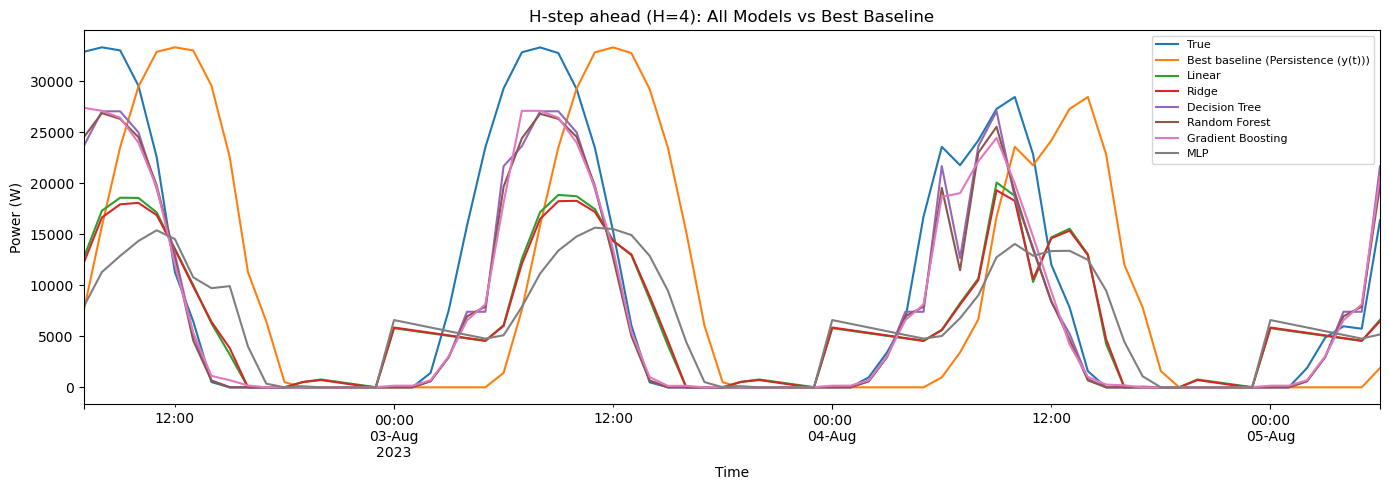

In [31]:
# AI-assisted (Claude Code): extended to include Decision Tree, Random Forest,
# Gradient Boosting, and MLP alongside the original baselines and Linear Regression.

# Local helper: returns (MAE, RMSE). Matches score_baseline from Appendix B.
def score(y_true, y_pred):
    aligned = pd.concat([y_true, y_pred.loc[y_true.index]], axis=1,
                        keys=["y", "yhat"]).dropna()
    err = aligned["y"] - aligned["yhat"]
    return err.abs().mean(), float(np.sqrt((err ** 2).mean()))

H = CONFIG["H"]

# Shift the target backwards so that each row's y_future contains the power
# output H steps into the future relative to the input features at that row.
y_future = pv_single["power_W"].shift(-H)

# Build the supervised table with current power, two lags, and hour of day.
supervised_h = pd.DataFrame({
    "y_future": y_future,
    "power_t": pv_single["power_W"],
    "lag_1": pv_single["power_W"].shift(1),
    "lag_day": pv_single["power_W"].shift(steps_per_day),
    "hour": pv_single.index.hour,
}).dropna()

# Chronological split.
split_idx = int(len(supervised_h) * CONFIG["TRAIN_FRAC"])
train_h = supervised_h.iloc[:split_idx]
val_h = supervised_h.iloc[split_idx:]

y_train_h = train_h["y_future"]
y_val_h = val_h["y_future"]

X_train_h = train_h[["power_t", "lag_1", "lag_day", "hour"]]
X_val_h = val_h[["power_t", "lag_1", "lag_day", "hour"]]

# Naive baselines for the H-step task:
# - Persistence: assume power in H hours equals current power.
# - Same-time-yesterday: use yesterday's value at the same hour.
# - Rolling mean: smoothed recent history (not shifted by H, so slightly optimistic).
pred_persistence_h = val_h["power_t"]
pred_same_time_h = val_h["lag_day"]
roll_mean_full = pv_single["power_W"].shift(1).rolling(
    window=CONFIG["ROLLING_K"], min_periods=CONFIG["ROLLING_K"]
).mean()
pred_roll_h = roll_mean_full.loc[val_h.index]

rows = []
baseline_series_map = {
    "Persistence (y(t))": pred_persistence_h,
    "Same time yesterday": pred_same_time_h,
    "Rolling mean 3h": pred_roll_h,
}
for name, pred in baseline_series_map.items():
    mae_v, rmse_v = score(y_val_h, pred)
    rows.append({"Model": name, "MAE": mae_v, "RMSE": rmse_v})


def fit_and_score_appendix(
    model_name: str, X_train, y_train, X_val, y_val, setting=None, config=CONFIG,
):
    """
    Fit a model using make_model and return predictions, MAE, and RMSE.

    Applies StandardScaler for models that require standardised inputs.
    Predictions are clipped to non-negative values since PV output cannot
    be negative, but no upper per-unit clip is applied because these
    appendices work with raw power in watts.
    """
    setting = setting or {}
    use_scale = model_name in config["SCALE_MODELS"]
    if use_scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train)
        X_v = scaler.transform(X_val)
    else:
        X_tr, X_v = X_train.values, X_val.values
    model = make_model(
        model_name, alpha=setting.get("alpha"), params=setting.get("params"), config=config,
    )
    with warnings.catch_warnings():
        if model_name == "MLP":
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
        model.fit(X_tr, y_train)
    pred = pd.Series(model.predict(X_v), index=X_val.index).clip(lower=0)
    mae_v, rmse_v = score(y_val, pred)
    return pred, mae_v, rmse_v


# Fit all model classes using hyperparameters from the multi-site sweep.
model_names_appendix = ["Linear", "Ridge", "Decision Tree", "Random Forest", "Gradient Boosting", "MLP"]
model_predictions = {}
for name in model_names_appendix:
    setting = best_model_settings.get(name, {})
    pred, mae_v, rmse_v = fit_and_score_appendix(
        name, X_train_h, y_train_h, X_val_h, y_val_h, setting,
    )
    model_predictions[name] = pred
    rows.append({"Model": name, "MAE": mae_v, "RMSE": rmse_v})

# Backward-compatible aliases used by Appendix E.
pred_lr_h = model_predictions["Linear"]
mae_lr, rmse_lr = score(y_val_h, pred_lr_h)

results_h = pd.DataFrame(rows).set_index("Model").sort_values("RMSE")
print(results_h)

# Identify the best naive baseline for comparison.
baseline_names = set(baseline_series_map.keys())
best_baseline_name = results_h.loc[results_h.index.isin(baseline_names), "RMSE"].idxmin()
best_baseline_series = baseline_series_map[best_baseline_name]

# Plot first 3 days: true target vs all models and the best naive baseline.
plot_len = steps_per_day * 3
plot_index = y_val_h.index[:plot_len]

plot_dict = {"True": y_val_h}
plot_dict[f"Best baseline ({best_baseline_name})"] = best_baseline_series
for name in model_names_appendix:
    plot_dict[name] = model_predictions[name]

plot_df = pd.DataFrame(plot_dict).loc[plot_index].dropna()
ax = plot_df.plot(figsize=(14, 5))
ax.set_title(f"H-step ahead (H={H}): All Models vs Best Baseline")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Preserved for Appendix H scatter plots (Appendix F reassigns y_val_h).
_appendix_d_y_val = y_val_h.copy()
_appendix_d_persistence = pred_persistence_h.copy()
_appendix_d_predictions = {k: v.copy() for k, v in model_predictions.items()}


## Appendix E: Ridge regression for H-step ahead

This appendix adds L2 regularisation (Ridge regression) to the H-step ahead single-site forecast from the previous appendix. Features are standardised before fitting so that the regularisation penalty is applied evenly across predictors with different scales. A small sweep over alpha values is used to find the best regularisation strength, and the result is compared against the unregularised Linear Regression and the best naive baseline. This appendix is kept Ridge-only because its purpose is to illustrate regularisation sensitivity rather than to compare model classes.

   alpha          MAE         RMSE
3  100.0  4533.150926  6631.838428
2   10.0  4549.103462  6632.002288
1    1.0  4551.800815  6632.670324
0    0.1  4552.079612  6632.744853
                                            MAE         RMSE
Best baseline (Persistence (y(t)))  6080.615924  9790.148591
Linear Regression                   4293.092099  6527.813103
Ridge (alpha=100)                   4533.150926  6631.838428


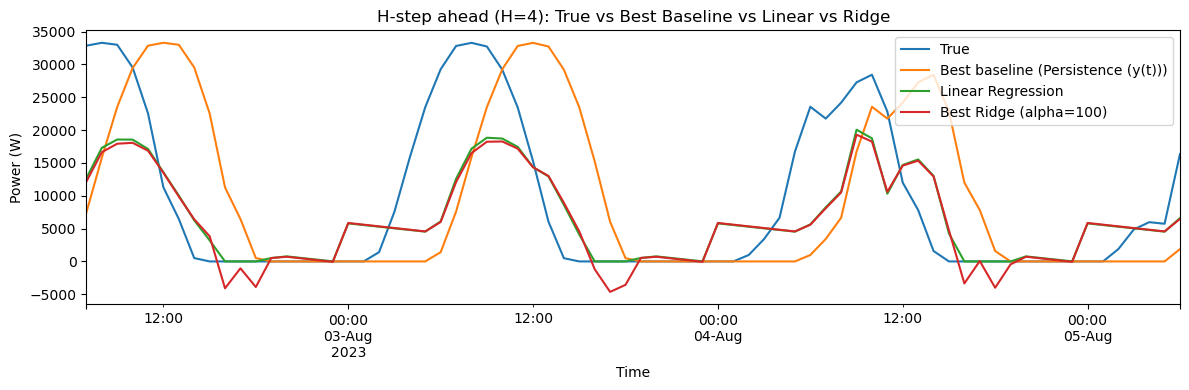

In [32]:
# Sweep over a range of L2 regularisation strengths.
alphas = [0.1, 1, 10, 100]

# Standardise features so that Ridge penalises all coefficients on the same scale.
# The scaler is fitted on training data only to avoid test-set leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_h)
X_val_scaled = scaler.transform(X_val_h)

ridge_results = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_h)
    pred = pd.Series(ridge.predict(X_val_scaled), index=X_val_h.index)
    mae, rmse_v = score(y_val_h, pred)
    ridge_results.append({"alpha": a, "MAE": mae, "RMSE": rmse_v, "pred": pred})

ridge_table = pd.DataFrame([{k: v for k, v in r.items() if k != "pred"} for r in ridge_results])
print(ridge_table.sort_values("RMSE"))

# Select the alpha that gave the lowest RMSE on the validation set.
best_ridge = min(ridge_results, key=lambda r: r["RMSE"])

# Side-by-side comparison: best baseline vs plain LR vs best Ridge.
compare = pd.DataFrame({
    "MAE": {
        f"Best baseline ({best_baseline_name})": results_h.loc[best_baseline_name, "MAE"],
        "Linear Regression": mae_lr,
        f"Ridge (alpha={best_ridge['alpha']})": best_ridge["MAE"],
    },
    "RMSE": {
        f"Best baseline ({best_baseline_name})": results_h.loc[best_baseline_name, "RMSE"],
        "Linear Regression": rmse_lr,
        f"Ridge (alpha={best_ridge['alpha']})": best_ridge["RMSE"],
    },
})
print(compare)

# Plot all three against the true target for visual comparison.
plot_df = pd.DataFrame({
    "True": y_val_h,
    f"Best baseline ({best_baseline_name})": best_baseline_series,
    "Linear Regression": pred_lr_h,
    f"Best Ridge (alpha={best_ridge['alpha']})": best_ridge["pred"],
}).loc[plot_index].dropna()

ax = plot_df.plot(figsize=(12, 4))
ax.set_title("H-step ahead (H=4): True vs Best Baseline vs Linear vs Ridge")
ax.set_xlabel("Time")
ax.set_ylabel("Power (W)")
plt.tight_layout()
plt.show()


## Appendix F: Multi-horizon H-step ahead forecasting

This appendix tests how forecast accuracy degrades as the prediction horizon increases, from 1 hour ahead up to a full day ahead. Persistence is compared against Linear Regression, Ridge, Decision Tree, Random Forest, Gradient Boosting, and MLP at each horizon. The resulting line chart shows RMSE versus horizon for each model, revealing whether the learned models degrade more gracefully than the naive persistence baseline and how far ahead each remains useful.

This analysis is useful for understanding the practical limits of the forecasting approach and for discussing in the report how the balance of model complexity shifts as the prediction task becomes harder.

    Horizon              Model          MAE          RMSE
0         1  Gradient Boosting  1518.641881   3046.317551
1         1      Random Forest  1551.761823   3135.096040
2         1      Decision Tree  1705.975527   3398.084866
3         1        Persistence  1887.404264   3473.790044
4         1                MLP  1972.119691   3768.530086
5         1             Linear  2511.294922   4151.621753
6         1              Ridge  2510.722593   4153.300014
7         4  Gradient Boosting  2518.558065   5154.838109
8         4      Random Forest  2547.146787   5282.572815
9         4      Decision Tree  2651.965148   5462.885854
10        4             Linear  3386.741020   5682.360227
11        4              Ridge  3393.824286   5692.389827
12        4                MLP  3366.567865   6379.604727
13        4        Persistence  6080.615924   9790.148591
14       16             Linear  3141.525091   5617.633746
15       16              Ridge  3148.730970   5628.452306
16       16   

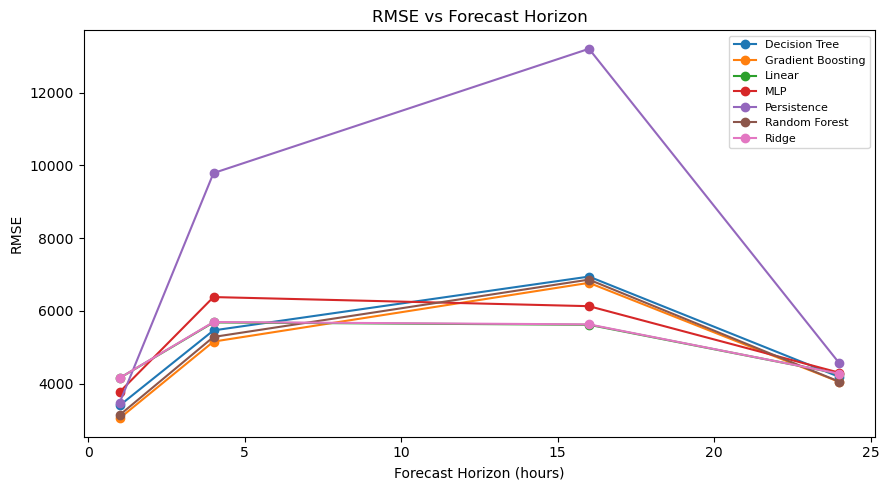

In [33]:
# AI-assisted (Claude Code): rewritten to use the same feature set and encoding
# as the main per-site pipeline (Section 8), so the multi-horizon comparison is
# directly consistent with the headline Q1 results rather than the reduced
# 4-feature appendix table. Cyclical hour/day/month/wind-direction encoding,
# the daylight indicator, and the full weather panel are all retained.

H_list = [1, 4, 16, steps_per_day]

# Build the consistent feature set on pv_single (the default site's
# PV+weather dataframe), matching feature_cols from Section 8.
def _build_consistent_supervised(df, H_val, weather_cols, config=CONFIG):
    """Build a supervised table for the default site at horizon H_val using
    the same features as the main per-site pipeline."""
    out = pd.DataFrame(index=df.index)
    out["y_future"] = df["power_W"].shift(-H_val)

    # Lag features (same definitions as Section 8).
    out["lag_1"] = df["power_W"].shift(1)
    out["lag_day"] = df["power_W"].shift(steps_per_day)

    # Cyclical calendar encoding.
    hours = df.index.hour
    dows = df.index.dayofweek
    months = df.index.month - 1
    out["hour_sin"] = np.sin(2 * np.pi * hours / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hours / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dows / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dows / 7)
    out["month_sin"] = np.sin(2 * np.pi * months / 12)
    out["month_cos"] = np.cos(2 * np.pi * months / 12)

    # Daylight indicator from irradiance threshold.
    irr_col_local = next(
        (c for c in df.columns if c.startswith("irr_")), None
    )
    if irr_col_local is not None:
        out["is_daylight"] = (df[irr_col_local] > config["DAYLIGHT_IRR_THRESHOLD"]).astype(int)
    else:
        out["is_daylight"] = 0

    # Weather columns (excluding the raw wind-direction angle, which is
    # encoded cyclically below to match the main pipeline).
    model_weather = [c for c in weather_cols if c != "wind_wind_direction_degree"]
    for c in model_weather:
        if c in df.columns:
            out[c] = df[c]

    # Cyclical wind direction if available.
    if "wind_wind_direction_degree" in df.columns:
        wd_rad = np.deg2rad(df["wind_wind_direction_degree"])
        out["wind_dir_sin"] = np.sin(wd_rad)
        out["wind_dir_cos"] = np.cos(wd_rad)

    return out.dropna()


results_multi = []
for H_val in H_list:
    supervised_mh = _build_consistent_supervised(pv_single, H_val, weather_cols)

    # Chronological split, identical convention to Section 8.
    split_idx = int(len(supervised_mh) * CONFIG["TRAIN_FRAC"])
    train_mh = supervised_mh.iloc[:split_idx]
    val_mh = supervised_mh.iloc[split_idx:]

    feature_cols_mh = [c for c in supervised_mh.columns if c != "y_future"]
    X_train_mh = train_mh[feature_cols_mh]
    y_train_mh = train_mh["y_future"]
    X_val_mh = val_mh[feature_cols_mh]
    y_val_mh = val_mh["y_future"]

    # Persistence baseline at this horizon: predict that power H steps ahead
    # equals current power. Uses raw power_W from the source frame, aligned
    # to the validation index.
    pred_persistence = pv_single["power_W"].reindex(val_mh.index)
    mae_p, rmse_p = score(y_val_mh, pred_persistence)
    results_multi.append({"Horizon": H_val, "Model": "Persistence", "MAE": mae_p, "RMSE": rmse_p})

    # Fit each tuned model class using the best settings selected in Section 12.
    for name in model_names_appendix:
        setting = best_model_settings.get(name, {})
        _, mae_v, rmse_v = fit_and_score_appendix(
            name, X_train_mh, y_train_mh, X_val_mh, y_val_mh, setting,
        )
        results_multi.append({"Horizon": H_val, "Model": name, "MAE": mae_v, "RMSE": rmse_v})

results_multi = pd.DataFrame(results_multi).sort_values(["Horizon", "RMSE"]).reset_index(drop=True)
print(results_multi)

# Line chart of RMSE vs forecast horizon for each model.
plot_df = results_multi.pivot(index="Horizon", columns="Model", values="RMSE").sort_index()
ax = plot_df.plot(marker="o", figsize=(9, 5))
ax.set_title("RMSE vs Forecast Horizon")
ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("RMSE")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Appendix G: Weather features vs no-weather ablation (H=1, 4)

This appendix tests whether adding meteorological features (irradiance, temperature, humidity, wind, etc.) to the model improves forecast accuracy compared to using only PV lag features and hour of day. Linear Regression, Ridge, Random Forest, and Gradient Boosting are each trained twice — once with and once without weather inputs — at two forecast horizons (H=1 and H=4).

This is a simple ablation study: by removing one group of features and measuring the change in error, it isolates the contribution of weather data to forecast performance. If weather features help, it confirms that the models are learning a physically meaningful relationship between atmospheric conditions and PV output rather than relying purely on temporal autocorrelation.

In [34]:
# AI-assisted (Claude Code): extended to include Random Forest and Gradient
# Boosting alongside Linear Regression and Ridge in the weather ablation.

def evaluate_models_with_weather(H_val, weather_cols):
    """
    Compare Linear Regression, Ridge, Random Forest, and Gradient Boosting
    with and without weather features at a given forecast horizon.

    Returns a long dataframe with one row per (model, feature-set) combination
    reporting MAE and RMSE on the chronological validation split.
    """
    y_future = pv_weather["power_W"].shift(-H_val)

    # Build the base feature table with lag features and hour.
    data = pd.DataFrame({
        "y_future": y_future,
        "power_t": pv_weather["power_W"],
        "lag_1": pv_weather["power_W"].shift(1),
        "lag_day": pv_weather["power_W"].shift(steps_per_day),
        "hour": pv_weather.index.hour,
    })

    # Append all available weather columns.
    for c in weather_cols:
        data[c] = pv_weather[c]
    data = data.dropna()

    split_idx = int(len(data) * CONFIG["TRAIN_FRAC"])
    train = data.iloc[:split_idx]
    val = data.iloc[split_idx:]
    y_train = train["y_future"]
    y_val = val["y_future"]

    base_features = ["power_t", "lag_1", "lag_day", "hour"]
    weather_features = base_features + list(weather_cols)

    ablation_models = ["Linear", "Ridge", "Random Forest", "Gradient Boosting"]
    results = []
    for name in ablation_models:
        setting = best_model_settings.get(name, {})

        # Without weather features.
        _, mae_nw, rmse_nw = fit_and_score_appendix(
            name, train[base_features], y_train, val[base_features], y_val, setting,
        )
        results.append({
            "Horizon": H_val, "Model": f"{name} (no weather)",
            "MAE": mae_nw, "RMSE": rmse_nw,
        })

        # With weather features.
        _, mae_w, rmse_w = fit_and_score_appendix(
            name, train[weather_features], y_train, val[weather_features], y_val, setting,
        )
        results.append({
            "Horizon": H_val, "Model": f"{name} (+ weather)",
            "MAE": mae_w, "RMSE": rmse_w,
        })

    return pd.DataFrame(results)


# Run the ablation at two horizons: 1-hour and 4-hour ahead.
H_compare = [1, 4]
results_weather = pd.concat(
    [evaluate_models_with_weather(H_val, weather_cols) for H_val in H_compare],
    ignore_index=True,
)
print(results_weather.sort_values(["Horizon", "RMSE"]))


    Horizon                           Model          MAE         RMSE
6         1  Gradient Boosting (no weather)  1088.914989  2234.713400
7         1   Gradient Boosting (+ weather)  1105.594549  2264.221776
4         1      Random Forest (no weather)  1098.804011  2288.392852
5         1       Random Forest (+ weather)  1131.306484  2336.065576
1         1              Linear (+ weather)  1672.629759  2796.006712
0         1             Linear (no weather)  1581.368633  2807.646717
3         1               Ridge (+ weather)  1695.131082  2822.971275
2         1              Ridge (no weather)  1623.101144  2839.086249
15        4   Gradient Boosting (+ weather)  2103.372278  3852.223414
14        4  Gradient Boosting (no weather)  2138.551399  4081.153905
12        4      Random Forest (no weather)  2166.641869  4168.881141
13        4       Random Forest (+ weather)  2227.794416  4263.022017
9         4              Linear (+ weather)  4540.467928  6497.567444
11        4         

## Appendix H: Predicted vs actual scatter plots

This appendix provides a visual diagnostic of forecast quality for the default site's test set at H=4. For four representative models (Persistence, Linear Regression, Gradient Boosting, and Random Forest), a scatter plot of predicted versus actual power output is shown. Points lying on the diagonal indicate perfect predictions; spread away from the diagonal reflects forecast error. Each subplot is titled with the model name and its RMSE. Semi-transparent markers are used to reveal the density structure of the prediction errors.

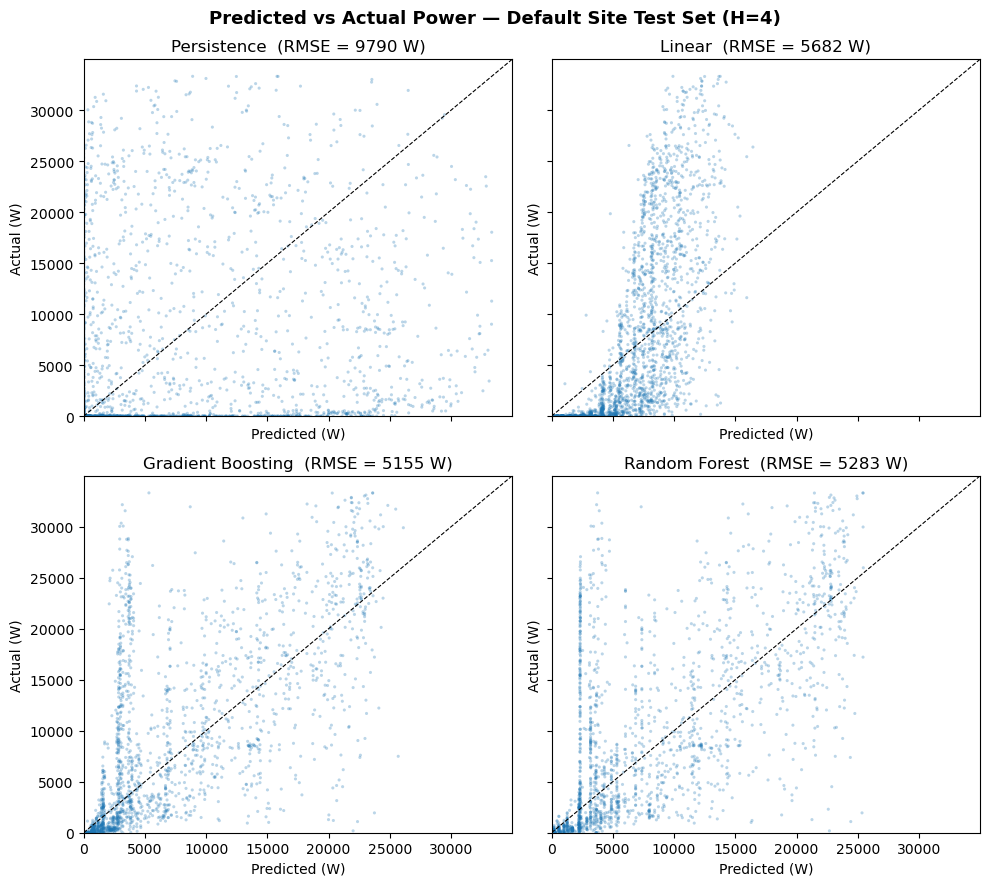

In [35]:
# AI-assisted (Claude Code): rebuilt to use the same feature set as the main
# per-site pipeline, so the scatter diagnostic is consistent with the headline
# Q1 results rather than the reduced 4-feature appendix table.

H = CONFIG["H"]
supervised_scatter = _build_consistent_supervised(pv_single, H, weather_cols)

split_idx = int(len(supervised_scatter) * CONFIG["TRAIN_FRAC"])
train_sc = supervised_scatter.iloc[:split_idx]
val_sc = supervised_scatter.iloc[split_idx:]

feature_cols_sc = [c for c in supervised_scatter.columns if c != "y_future"]
X_train_sc = train_sc[feature_cols_sc]
y_train_sc = train_sc["y_future"]
X_val_sc = val_sc[feature_cols_sc]
y_val_sc = val_sc["y_future"]

# Persistence: predict that power H steps ahead equals current power.
pred_persistence_sc = pv_single["power_W"].reindex(val_sc.index)

# Fit the four models for the scatter diagnostic, using tuned hyperparameters.
scatter_predictions = {"Persistence": pred_persistence_sc}
for name in ["Linear", "Gradient Boosting", "Random Forest"]:
    setting = best_model_settings.get(name, {})
    pred, _, _ = fit_and_score_appendix(
        name, X_train_sc, y_train_sc, X_val_sc, y_val_sc, setting,
    )
    scatter_predictions[name] = pred

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, (name, pred) in zip(axes.flat, scatter_predictions.items()):
    aligned = pd.concat(
        [y_val_sc, pred], axis=1, keys=["actual", "predicted"],
    ).dropna()
    _, rmse_v = score(aligned["actual"], aligned["predicted"])
    ax.scatter(
        aligned["predicted"], aligned["actual"],
        alpha=0.3, s=5, edgecolors="none",
    )
    lims = [0, max(aligned["actual"].max(), aligned["predicted"].max()) * 1.05]
    ax.plot(lims, lims, "k--", linewidth=0.8)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{name}  (RMSE = {rmse_v:.0f} W)")
    ax.set_xlabel("Predicted (W)")
    ax.set_ylabel("Actual (W)")

plt.suptitle(
    f"Predicted vs Actual Power \u2014 Default Site Test Set (H={CONFIG['H']})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

## Appendix I: Report verification

The two cells below compute specific numerical claims made in the report, so the reported values can be verified directly against the notebook. Cell 1 confirms site metadata and irradiance statistics for the Q1 typical (SQ8) and hard (Zone A2) cases. Cell 2 confirms the cross-site eligible/holdout split, the Q2 example site, and per-site GB-vs-persistence comparisons for the LOSO spot check.

In [36]:
# Verify caption claims for Q1 typical case (SQ8) and hard case (Zone A2)
for site_id in ["SQ8", "Zone A2"]:
    raw = site_splits[site_id]["raw_train"]
    rated_kW = raw["rated_power_W"].dropna().iloc[0] / 1000
    tilt = raw["tilt_deg"].dropna().iloc[0] if raw["tilt_deg"].notna().any() else "n/a"
    azimuth = raw["azimuth_deg"].dropna().iloc[0] if raw["azimuth_deg"].notna().any() else "n/a"
    mixed = raw["mixed_orientation"].dropna().iloc[0] if raw["mixed_orientation"].notna().any() else "n/a"
    print(f"{site_id}: {rated_kW:.1f} kW, tilt={tilt}, azimuth={azimuth}, mixed_orientation={mixed}")

# Irradiance comparison: plotted window vs full test set for SQ8
irr_col = [c for c in site_splits["SQ8"]["test"].columns if c.startswith("irr_")][0]
sq8_test = site_splits["SQ8"]["test"]
window_irr = sq8_test[irr_col].iloc[:steps_per_day * 3].mean()
full_irr = sq8_test[irr_col].mean()
print(f"\nSQ8 plotted window mean irradiance: {window_irr:.1f} W/m²")
print(f"SQ8 full test set mean irradiance:  {full_irr:.1f} W/m²")

window_idx = sq8_test.iloc[:steps_per_day * 3].index
print(f"SQ8 plotted window dates: {window_idx[0]} to {window_idx[-1]}")

SQ8: 32.5 kW, tilt=n/a, azimuth=n/a, mixed_orientation=1
Zone A2: 249.5 kW, tilt=0.0, azimuth=0.0, mixed_orientation=0

SQ8 plotted window mean irradiance: 78.9 W/m²
SQ8 full test set mean irradiance:  213.1 W/m²
SQ8 plotted window dates: 2023-06-14 21:00:00 to 2023-06-18 06:00:00


In [37]:
# Report fact-check: print numbers that appear in Q2 prose so wording can be
# locked against the actual run.
print(f"Eligible cross-site sites: {len(cross_site_eligible)}")
print(f"Held-out: {len(heldout_sites)}, Pooled training: {len(train_pool_sites)}")
print(f"Q2 example site: {q2_site_id}, rated power: "
      f"{site_splits[q2_site_id]['raw_train']['rated_power_W'].dropna().iloc[0]/1000:.1f} kW")

# Compare GB vs persistence per LOSO site
print("\nLOSO: pooled GB vs persistence NRMSE per held-out site:")
for sid in loso_sites:
    gb_row = loso_results[
        (loso_results["site_id"] == sid)
        & (loso_results["model"] == "Gradient Boosting")
        & (loso_results["variant"] == "metadata + history")
    ]
    pers_row = persist_df[persist_df["site_id"] == sid]
    if not gb_row.empty and not pers_row.empty:
        gb_n = gb_row["NRMSE_p95"].iloc[0]
        pers_n = pers_row["NRMSE_p95"].iloc[0]
        beats = "GB beats persistence" if gb_n < pers_n else "persistence beats GB"
        print(f"  {sid}: GB={gb_n:.3f}, persistence={pers_n:.3f} -> {beats}")

Eligible cross-site sites: 40
Held-out: 8, Pooled training: 32
Q2 example site: LSK South, rated power: 25.0 kW

LOSO: pooled GB vs persistence NRMSE per held-out site:
  UG Hall2 RF: GB=0.125, persistence=0.307 -> GB beats persistence
  Zone A2: GB=0.422, persistence=1.049 -> GB beats persistence
  UG Hall7: GB=0.189, persistence=0.359 -> GB beats persistence
